# **Dubai Residential Property Valuation Model**

Estimating transaction value from property characteristics using historical Dubai Land Department sales records.

## 1. Introduction

Dubai's residential real estate market is one of the most active in the world. With over 1.6 million transactions so far, it recorded over 265,000 sales transactions in 2025 alone. Accurate property valuation is practically important as it helps buyers, sellers, investors, and agents benchmark a fair price against objective property characteristics such as location, size, type, and room count.

This notebook builds a **property valuation model** using a supervised regression model that estimates the transaction value of a residential property given its characteristics. This is distinct from a price forecasting model. The goal is not to predict what prices will be in the future, but to estimate what a property is worth based on patterns learned from historical market transactions.

## 2. Dataset Source and Acquisition

The Dubai Real Estate Transactions dataset was sourced from the **Dubai Pulse Open Data Portal**, the official open data platform of the Government of Dubai.

- **Source URL:** https://data.dubai/en/l/470061
- **Publisher:** Dubai Land Department (DLD)
- **Access method:** Downloaded as a `.csv` file (976 MB) and uploaded the raw dataset to Hugging Face for reproducible loading.
- **Hosted dataset:** https://huggingface.co/datasets/mohd3rfan/DLD_Transactions
- **Time coverage:** Up to 1 January 2026
- **Rows (raw dataset):** 1,661,875 transactions


**Ethics and permissions:** The dataset is published under Dubai's open data policy for public use. No personal or sensitive data about individuals is present. Records represent property transactions only.

**Why this dataset:** It is locally relevant, government-sourced, large-scale, recent, and provides a genuine modelling challenge. The dataset has not been used in any tutorials and was not chosen based on existing online notebook solutions.

## 3. Supervised Learning  Task

**Target variable:** `actual_worth` — the recorded transaction price in AED.

**Problem type:** Regression.

**Purpose of the model:** Property valuation. Given a property's characteristics (location, size, type, room count, parking, metro proximity, registration type, and transaction timing), estimate its transaction value at current market rates.

 The prediction is meaningful because it enables fair-price benchmarking without requiring manual appraisal.

**Important distinction:** This model reflects market rates learned from the 2021–2025 training period. It is not a time-series forecasting model and should not be used to project future price levels.

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn lightgbm optuna --quiet

In [ ]:
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"Global seed set to {SEED}")

Global seed set to 42


In [ ]:
dataset = pd.read_csv('https://huggingface.co/datasets/mohd3rfan/DLD_Transactions/resolve/main/Transactions.csv?download=true')
pd.set_option('display.max_colwidth', None)

In [ ]:
df = dataset.copy()

In [ ]:
df.head()

,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,property_type_ar,...,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,3-9-2006-163,9,3,هبات,Gifts,هبه,Grant,16-10-2006,4,فيلا,...,NaN,0,3162.42,12000000.0,3794.56,NaN,NaN,3.0,1.0,0.0
1,3-9-2019-2944,9,3,هبات,Gifts,هبه,Grant,13-11-2019,1,أرض,...,NaN,0,209.09,916659.0,4384.04,NaN,NaN,2.0,4.0,0.0
2,2-13-1999-347,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,22-03-1999,1,أرض,...,NaN,0,1062.72,1200000.0,1129.18,NaN,NaN,1.0,1.0,0.0
3,2-13-2001-547,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,23-07-2001,2,مبنى,...,NaN,0,1393.55,3500000.0,2511.57,NaN,NaN,5.0,1.0,0.0
4,2-13-2020-9477,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,30-11-2020,2,مبنى,...,NaN,0,278.71,2500000.0,8969.90,NaN,NaN,1.0,1.0,0.0


### Dataset Shape

After loading, the raw dataset contains 1,661,875 rows and 46 columns (including both Arabic and English versions of each field). The following cells inspect the structure and begin cleaning.

In [ ]:
df.shape

(1661875, 46)

In [ ]:
df.columns

Index(['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_ar',
       'trans_group_en', 'procedure_name_ar', 'procedure_name_en',
       'instance_date', 'property_type_id', 'property_type_ar',
       'property_type_en', 'property_sub_type_id', 'property_sub_type_ar',
       'property_sub_type_en', 'property_usage_ar', 'property_usage_en',
       'reg_type_id', 'reg_type_ar', 'reg_type_en', 'area_id', 'area_name_ar',
       'area_name_en', 'building_name_ar', 'building_name_en',
       'project_number', 'project_name_ar', 'project_name_en',
       'master_project_en', 'master_project_ar', 'nearest_landmark_ar',
       'nearest_landmark_en', 'nearest_metro_ar', 'nearest_metro_en',
       'nearest_mall_ar', 'nearest_mall_en', 'rooms_ar', 'rooms_en',
       'has_parking', 'procedure_area', 'actual_worth', 'meter_sale_price',
       'rent_value', 'meter_rent_price', 'no_of_parties_role_1',
       'no_of_parties_role_2', 'no_of_parties_role_3'],
      dtype='object')

### Removing Arabic Columns and Standardising Column Names

Each field in the raw dataset has both an Arabic (`_ar`) and English (`_en`) version. We retain only the English columns and strip the `_en` suffix for cleaner column names. This halves the column count without losing any information.

In [ ]:
columns_to_process = []
rename_mapping = {}

for col in df.columns:
    if col.endswith('_ar'):
        # Skipping Arabic columns
        continue
    elif col.endswith('_en'):
        columns_to_process.append(col)
        rename_mapping[col] = col.replace('_en', '')

    else:
        columns_to_process.append(col)

df = df[columns_to_process]

# Renaming selected columns
df = df.rename(columns=rename_mapping)

In [ ]:
df.shape

(1661875, 32)

After removing Arabic columns, the dataset has 32 columns.

### Missing Value Assessment

Before dropping any columns, we inspect null value counts across all features. This informs which columns are complete enough to use and which require imputation or removal.

In [ ]:
print(df.isnull().sum().sort_values(ascending=False))

rent_value              1625339
meter_rent_price        1625339
nearest_mall             511398
nearest_metro            501631
building_name            479561
project_number           456139
project_name             456139
rooms                    357962
property_sub_type        334347
property_sub_type_id     334347
nearest_landmark         320582
master_project           225661
no_of_parties_role_2        969
no_of_parties_role_1        969
no_of_parties_role_3        969
transaction_id                0
area_name                     0
area_id                       0
reg_type                      0
reg_type_id                   0
property_usage                0
instance_date                 0
property_type_id              0
property_type                 0
trans_group                   0
trans_group_id                0
procedure_id                  0
procedure_name                0
has_parking                   0
meter_sale_price              0
procedure_area                0
actual_w

## 5. Data Cleaning and Preprocessing

### Column Selection

The following columns are removed before modelling. Each removal is justified:

- **Identifiers** (`transaction_id`, `procedure_id`, `trans_group_id`, `area_id`, `property_type_id`, `property_sub_type_id`, `reg_type_id`, `project_number`): Integer keys with no predictive signal for property value.
- **High cardinality project metadata** (`project_name`, `master_project`, `building_name`): Thousands of unique values, most with very few transactions. Including these as features would cause extreme sparsity after encoding and would not generalise.
- **Procedure name** (`procedure_name`): Text field with no consistent structure useful for valuation.
- **Nearest landmark** (`nearest_landmark`): Low generalisation and too granular and incomplete.
- **Rent related fields** (`rent_value`, `meter_rent_price`): Not relevant to sales transaction valuation.
- **Party count fields** (`no_of_parties_role_1/2/3`): Administrative metadata unrelated to property value.

These removals reduce noise, prevent potential data leakage from administratively-derived fields, and keep the feature space focused on characteristics that genuinely drive property valuation.

In [ ]:
cols_to_drop = [
    'transaction_id', 'property_type_id', 'property_sub_type_id', 'reg_type_id', 'area_id', 'procedure_name', 'project_name',
    'master_project', 'procedure_id', 'trans_group_id',
    'project_number', 'building_name',
    'nearest_landmark',
    'rent_value', 'meter_rent_price','no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3'
]
df = df.drop(columns=cols_to_drop)

In [ ]:
df.shape

(1661875, 14)

After column selection, 14 columns remain. These cover transaction timing, property characteristics, location, and the target variable `actual_worth`.

In [ ]:
print(df.isnull().sum().sort_values(ascending=False))

nearest_mall         511398
nearest_metro        501631
rooms                357962
property_sub_type    334347
instance_date             0
trans_group               0
reg_type                  0
property_usage            0
property_type             0
area_name                 0
has_parking               0
procedure_area            0
actual_worth              0
meter_sale_price          0
dtype: int64


In [ ]:
def column_values(dataframe):
  for col in dataframe.columns:
    if dataframe[col].dtype == 'object':
      print(f"{dataframe[col].value_counts()}")
      print()

In [ ]:
column_values(df)

trans_group
Sales        1272224
Mortgages     328311
Gifts          61340
Name: count, dtype: int64

instance_date
11-09-2023    2847
03-03-2010    2295
26-10-2009    2196
29-12-2025    2132
21-07-2025    1873
              ... 
14-05-2010       1
23-06-1975       1
22-07-1991       1
22-06-1992       1
10-10-1988       1
Name: count, Length: 6575, dtype: int64

property_type
Unit        1182314
Villa        295907
Land         147600
Building      36054
Name: count, dtype: int64

property_sub_type
Flat                  1052621
Villa                  144949
Office                  70252
Hotel Apartment         27739
Shop                    17092
Hotel Rooms             12789
Workshop                  556
Stacked Townhouses        522
Store                     320
Building                  269
Warehouse                 162
Clinic                     68
Show Rooms                 66
Hotel                      44
Sized Partition            43
Gymnasium                  30
Parking        

### Filtering to Sales Transactions Only

The `trans_group` column includes three transaction types: Sales, Mortgages, and Gifts. For a property valuation model, only **Sales** transactions represent arms-length market prices — the price a willing buyer pays a willing seller. Mortgages reflect financing values (which may differ from market price), and Gifts are non-market transfers at nominal or zero value. Including them would distort the price distribution and mislead the model. We retain Sales only.

In [ ]:
df = df[df['trans_group'] == 'Sales']

### Missing Value Imputation and Feature Extraction

`instance_date` is parsed as a datetime column. Any unparseable dates are coerced
to `NaT` and filled with the column median.

`year` and `month` are extracted from `instance_date` as numeric features to
capture market level temporal trends.

`rooms` nulls are filled with `'Unknown'` and `property_sub_type` nulls with
`'Others'` before category cleaning, so no rows are dropped due to missing labels.

The `clean_room_category` function standardises the raw room strings into consistent
categories.
We merged synonyms (e.g. 'Single Room' → Studio) and identified commercial
uses (offices, shops).

We extracted bedroom counts to `rooms_to_numeric` by mapping
each category to a numeric value, with Studio encoded as 0.5 to place
it correctly between 0 (unknown/commercial) and 1 (1 bedroom) on the ordinal scale.

In [ ]:
df['instance_date'] = pd.to_datetime(df['instance_date'], errors='coerce')
df['instance_date'].fillna(df['instance_date'].median(), inplace=True)

# year and month
df['year'] = df['instance_date'].dt.year
df['month'] = df['instance_date'].dt.month

df['rooms'] = df['rooms'].fillna('Unknown')

# Property sub type NaNs
df['property_sub_type'] = df['property_sub_type'].fillna('Others')

def clean_room_category(x):

    x = x.strip().lower()

    # Commercial categories
    commercial_terms = ['office', 'shop', 'store', 'gym']
    if any(term in x for term in commercial_terms):
        return 'Commercial'

    # Merging categories
    if 'single' in x:
        return 'Studio'
    if 'studio' in x:
        return 'Studio'
    if 'penthouse' in x:
        return 'Penthouse'

    # Bedroom numbers
    for i in range(1, 11):
        if f'{i}' in x[:2]:
            return f'{i} Bedroom'

    return 'Other'


def rooms_to_numeric(x):
    mapping = {
        'Studio': 0.5,
        '1 Bedroom': 1,
        '2 Bedroom': 2,
        '3 Bedroom': 3,
        '4 Bedroom': 4,
        'Penthouse': 5,
        '5 Bedroom': 5,
        '6 Bedroom': 6,
        '7 Bedroom': 7,
        '8 Bedroom': 8,
        '9 Bedroom': 9,
        '10 Bedroom': 10,
        'Commercial': 0,
        'Other': 0,
    }
    return mapping.get(x, 0)

df['rooms'] = df['rooms'].apply(clean_room_category)
df['rooms_numeric'] = df['rooms'].apply(rooms_to_numeric)


In [ ]:
df.shape

(1272224, 17)

In [ ]:
print(df.isnull().sum().sort_values(ascending=False))

nearest_mall         408822
nearest_metro        400833
trans_group               0
instance_date             0
property_type             0
property_usage            0
property_sub_type         0
area_name                 0
reg_type                  0
rooms                     0
has_parking               0
procedure_area            0
actual_worth              0
meter_sale_price          0
year                      0
month                     0
rooms_numeric             0
dtype: int64


In [ ]:
print(df['rooms_numeric'].value_counts().sort_index())

rooms_numeric
0.0    266241
0.5    210120
1.0    377966
2.0    242937
3.0    125699
4.0     42855
5.0      6058
6.0       289
7.0        53
8.0         3
9.0         3
Name: count, dtype: int64


### Room Category Consolidation

Properties with more than 4 bedrooms (5, 6, 7, 8, 9, 10 bedrooms and Penthouses) each have very few transactions. The distribution is heavily right-skewed with a long tail. With very few transactions per category, the model might not be able to learn reliable patterns for these groups, and including them separately adds noise.

We consolidated all properties with more than 4 bedrooms into a single **"4+ Rooms / Luxury"** category, encoded as `rooms_numeric = 5`.


Therefore, the full numeric mapping for rooms count is as follows:

| Category | rooms_numeric |
|----------|--------------|
| Studio | 0.5 |
| 1 Bedroom | 1.0 |
| 2 Bedroom | 2.0 |
| 3 Bedroom | 3.0 |
| 4 Bedroom | 4.0 |
| 4+ / Luxury / Penthouse | 5.0 |
| Commercial / Unknown | 0.0 (later removed) |

This consolidation improves model stability without discarding meaningful information. In addition, the size feature (`procedure_area`) will capture most of the price premium for large properties.

In [ ]:
df['rooms_numeric'] = df['rooms_numeric'].apply(lambda x: 5 if x > 4 else x)

### Proximity Feature Engineering

Rather than using the raw `nearest_metro` and `nearest_mall` text columns (which
contain different variable landmark names unsuitable for direct encoding), we derived
two binary flags: `is_near_metro` and `is_near_mall`. A value of 1 indicates the
property has a recorded nearby metro station or mall; 0 indicates none was recorded.

In [ ]:
df['is_near_metro'] = np.where(df['nearest_metro'].notna(), 1, 0)
df['is_near_mall'] = np.where(df['nearest_mall'].notna(), 1, 0)

### Initial Year Range Filter

Transactions outside the 2015–2025 range are filtered out. Records before 2015
are sparse and reflects a different market environment. This filter is applied to the full dataset before the later step that restricts the modelling dataset to 2021 onwards. The 2015–2020 period is retained here for the initial trend visualisation.

In [ ]:
df = df[(df['year'] >= 2015) & (df['year'] < 2026)]

In [ ]:
print(df.isnull().sum().sort_values(ascending=False))

nearest_mall         344567
nearest_metro        338814
trans_group               0
property_type             0
instance_date             0
property_sub_type         0
property_usage            0
area_name                 0
reg_type                  0
rooms                     0
has_parking               0
procedure_area            0
actual_worth              0
meter_sale_price          0
year                      0
month                     0
rooms_numeric             0
is_near_metro             0
is_near_mall              0
dtype: int64


In [ ]:
import matplotlib.dates as mdates

def plot_transaction_trends(
    dataframe = None,
    value_col= None,
    agg_col= None,
    start_year=None,
    end_year=None
):
    """
    Plots transaction count and aggregated price trend over time.

    Parameters:
    df : pandas DataFrame
    value_col : column for aggregation (default 'actual_worth')
    agg_col : 'median' or 'mean'
    start_year : filter start year (optional)
    end_year : filter end year (optional)
    """

    data = dataframe.copy()

    if start_year is not None:
        data = data[data['year'] >= start_year]
    if end_year is not None:
        data = data[data['year'] <= end_year]

    # Aggregation function
    agg_func = 'median' if agg_col == None else agg_col

    df_plot = data.groupby(['year', 'month']).agg(
        transaction_count=(value_col, 'count'),
        price_stat=(value_col, agg_func)
    ).reset_index()

    df_plot['date'] = pd.to_datetime(
        df_plot['year'].astype(str) + '-' +
        df_plot['month'].astype(str) + '-01'
    )

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

    # Transaction count
    axes[0].plot(df_plot['date'], df_plot['transaction_count'], color='blue')
    axes[0].set_ylabel('Transaction Count')
    axes[0].set_title('Transaction Count')
    axes[0].grid(True)

    # Price trend
    axes[1].plot(df_plot['date'], df_plot['price_stat'], color='red')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel(f'{agg_col.title()} {value_col}')
    axes[1].set_title(f'{agg_col.title()} {value_col}')
    axes[1].grid(True)

    axes[1].xaxis.set_major_locator(mdates.YearLocator())
    axes[1].xaxis.set_minor_locator(mdates.MonthLocator())

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

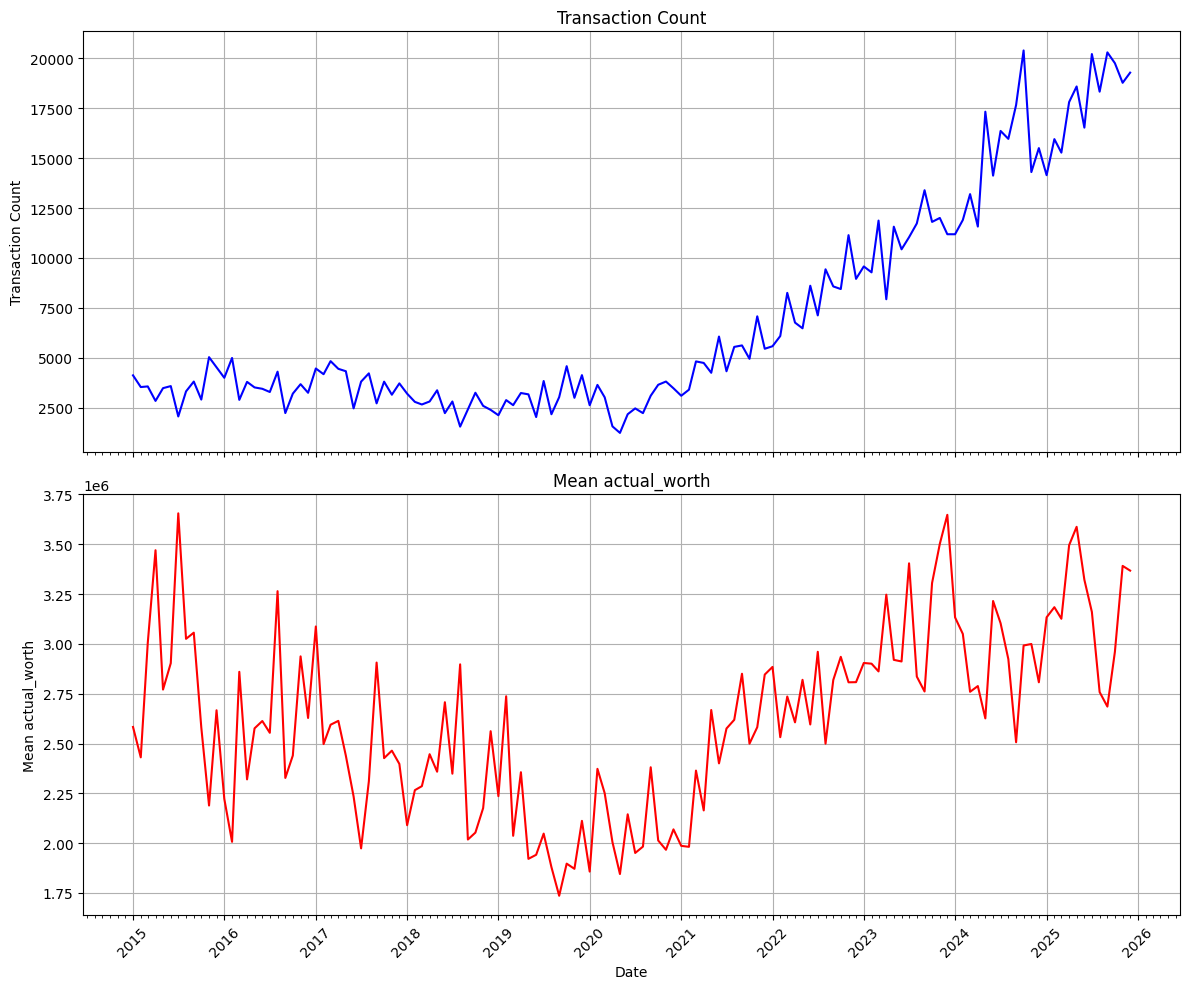

In [ ]:
plot_transaction_trends(dataframe = df, value_col='actual_worth', agg_col='mean', start_year=2015, end_year=2026)

In [ ]:
df.shape

(915029, 19)

The mean price trend plot shows sharp spikes at certain time periods, which is characteristic of outlier distortion. Extremely high value luxury transactions can inflate the mean significantly. We investigated the price distribution before proceeding to model training.

### Outlier Treatment

Property prices in Dubai are heavily right-skewed. The raw `actual_worth` column contains ultra-luxury transactions worth hundreds of millions of AED which is a tiny fraction of total volume, but enough to severely distort model training if included.

We applied **asymmetric percentile clipping**. We retained transactions between the 25th and 98th percentiles. The lower cut removed distressed sales, gifts misclassified as sales, and any data entry errors. The upper cut removed the ultra-luxury segment, which is too sparse to model reliably and operates under different market dynamics.

Therefore, the resulting model is calibrated for the mainstream residential market. It is not intended to value ultra-luxury properties.

In [ ]:
print(df['actual_worth'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.98, 0.99]))

count    9.150290e+05
mean     2.826731e+06
std      1.401142e+07
min      1.000000e+00
1%       2.499695e+05
5%       4.050000e+05
25%      8.090100e+05
50%      1.438888e+06
75%      2.600000e+06
95%      7.468888e+06
98%      1.540000e+07
99%      2.375975e+07
max      3.869204e+09
Name: actual_worth, dtype: float64


In [ ]:
lower = df['actual_worth'].quantile(0.25)
upper = df['actual_worth'].quantile(0.98)

In [ ]:
df_clean = df[(df['actual_worth'] >= lower) & (df['actual_worth'] <= upper)]

In [ ]:
print(df_clean['actual_worth'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.98, 0.99]))

count    6.679850e+05
mean     2.547214e+06
std      2.121241e+06
min      8.090100e+05
1%       8.258670e+05
5%       8.970180e+05
25%      1.250000e+06
50%      1.848000e+06
75%      2.989521e+06
95%      6.875000e+06
98%      9.962496e+06
99%      1.200000e+07
max      1.540000e+07
Name: actual_worth, dtype: float64


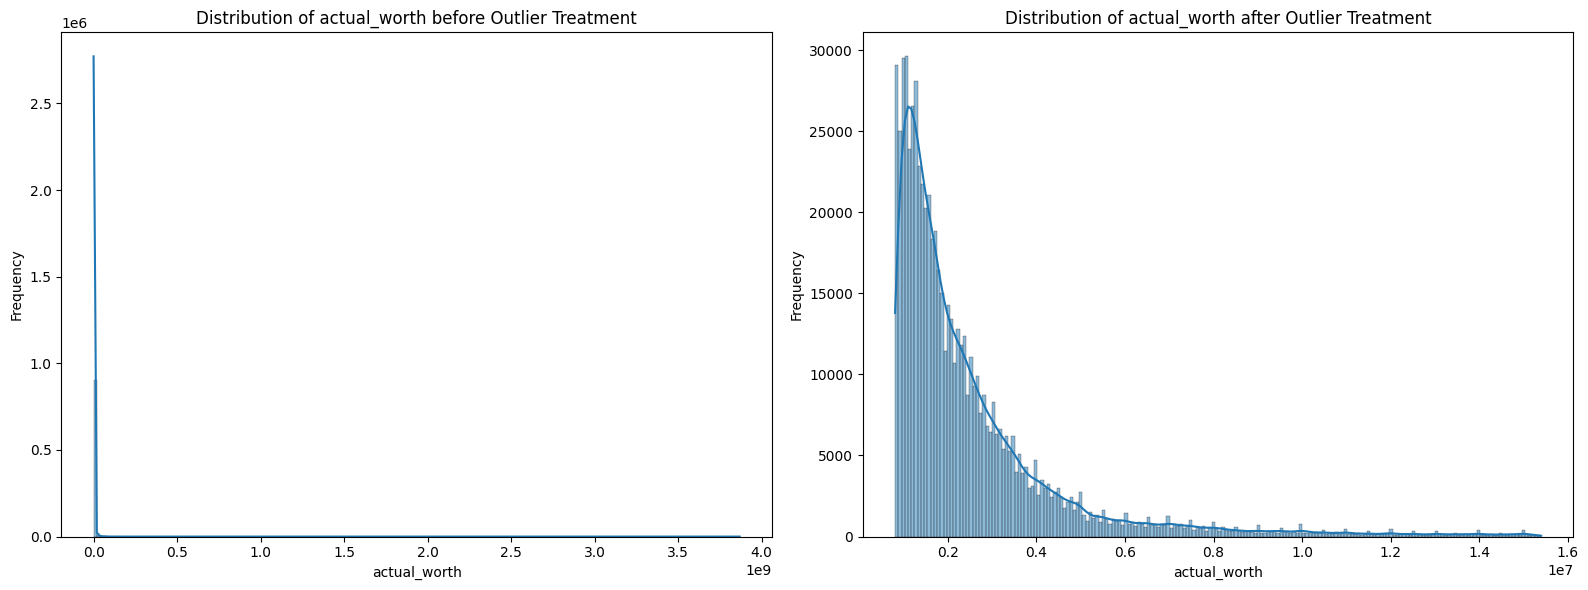

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['actual_worth'], kde=True, bins=200, ax=axes[0])
axes[0].set_title('Distribution of actual_worth before Outlier Treatment')
axes[0].set_xlabel('actual_worth')
axes[0].set_ylabel('Frequency')

sns.histplot(df_clean['actual_worth'], kde=True, bins=200, ax=axes[1])
axes[1].set_title('Distribution of actual_worth after Outlier Treatment')
axes[1].set_xlabel('actual_worth')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

The maximum price is now substantially reduced and the distribution is far less skewed, which will produce more stable log-transformed targets for modelling.

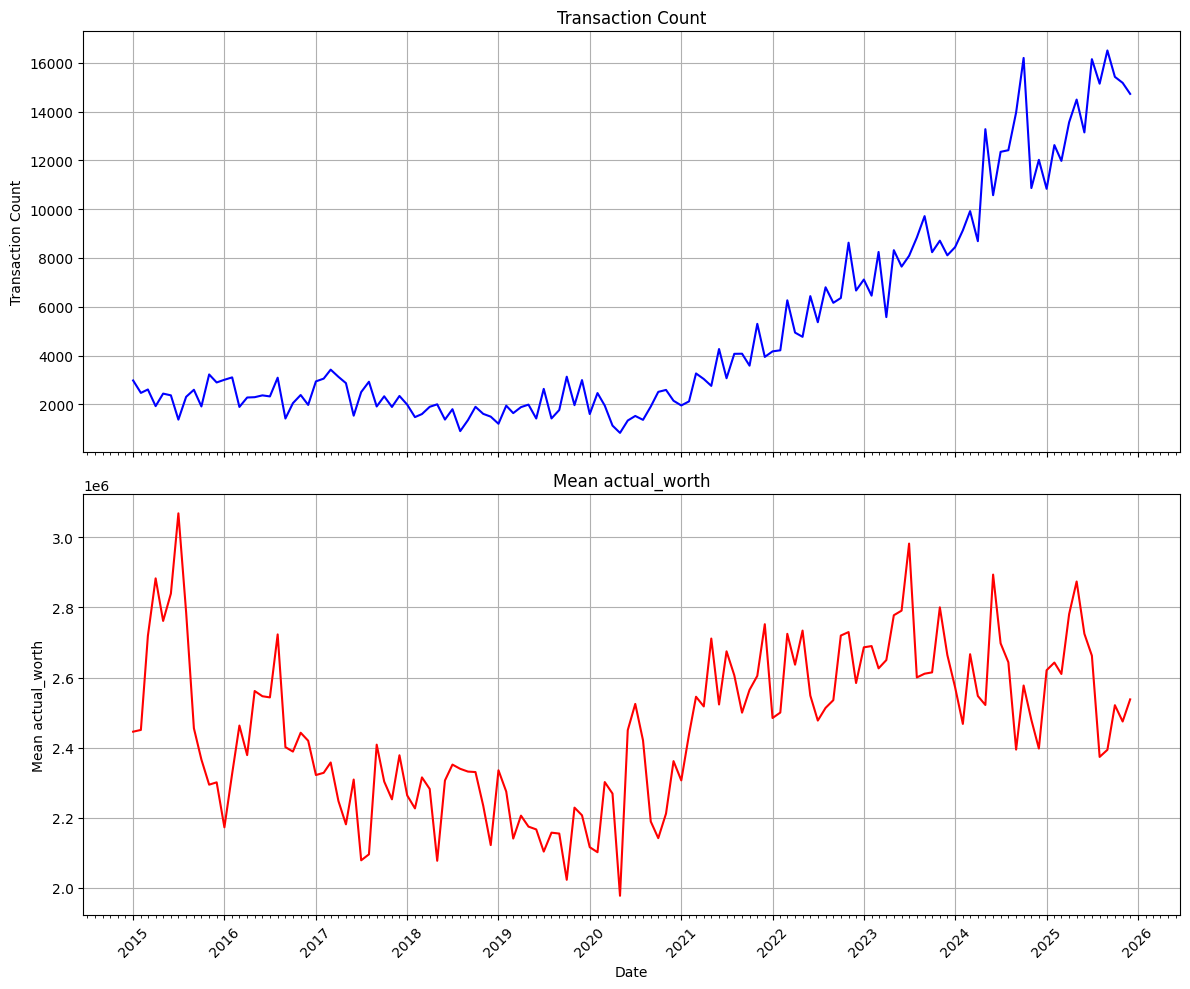

In [ ]:
plot_transaction_trends(dataframe = df_clean, value_col='actual_worth', agg_col='mean', start_year=2015, end_year=2026)

In [ ]:
df_clean.shape

(667985, 19)

Inspecting the Dataset for all categorical features

In [ ]:
column_values(df_clean)

trans_group
Sales    667985
Name: count, dtype: int64

property_type
Unit        477454
Villa       114846
Land         72723
Building      2962
Name: count, dtype: int64

property_sub_type
Flat                  436435
Others                110270
Villa                  80205
Office                 15347
Hotel Apartment        12381
Hotel Rooms             8373
Shop                    4406
Stacked Townhouses       339
Warehouse                 71
Building                  56
Clinic                    41
Show Rooms                36
Workshop                  15
Gymnasium                  7
Unit                       2
Hotel                      1
Name: count, dtype: int64

property_usage
Residential                 585670
Commercial                   45627
Hospitality                  20758
Other                        10899
Industrial                    2794
Multi-Use                     1940
Storage                        138
Agricultural                    93
Residential / Commercial

In [ ]:
print(df_clean['property_usage'].value_counts())

property_usage
Residential                 585670
Commercial                   45627
Hospitality                  20758
Other                        10899
Industrial                    2794
Multi-Use                     1940
Storage                        138
Agricultural                    93
Residential / Commercial        64
Industrial / Commercial          2
Name: count, dtype: int64


### Filtering to Residential Properties Only

The `property_usage` column includes Residential, Commercial, and other categories. This valuation model is specifically designed for **residential properties** like apartments, villas, and townhouses. Commercial properties (offices, retail units, warehouses) are priced under entirely different market dynamics and therefore should not be mixed into the same model.

In [ ]:
df_clean = df_clean[df_clean['property_usage'] == 'Residential']

Inspection of the `nearest_mall` column revealed inconsistent coverage. Several major Dubai malls (Dubai Hills Mall, Nad Al Sheba Mall, Nakheel Mall, Festival Plaza .etc) are absent from the dataset entirely. This means the column does not reliably capture proximity to shopping amenities for all properties, making it an unreliable signal for valuation.

We drop `nearest_mall` and its associated columns rather than risk injecting biased noise into the model.

With the dataset now filtered to Sales and Residential only, `trans_group` and `property_usage` are constant across all rows and carry no information. We also drop `nearest_metro` (replaced by the binary flags `is_near_metro`), `nearest_mall`, `is_near_mall`, `meter_sale_price` (which is `actual_worth` / `procedure_area`) and the original `rooms` string column (replaced by `rooms_numeric`).

In [ ]:
columns_to_drop = ['trans_group', 'nearest_metro', 'nearest_mall', 'rooms', 'is_near_mall', 'property_usage', 'meter_sale_price']
df_clean = df_clean.drop(columns=columns_to_drop)

### Restricting to 2021–2025 Transactions

From the trend plots we can understand the period between 2015 and 2020 was characterized by relatively low and stagnant market activity. Starting in early 2021, the market entered a period of exponential growth. Therefore, We limit the modelling dataset to transactions from 2021 onwards. Earlier years (2015–2020) reflect a different market context.

The 2021–2025 period captures the New Dubai economy, driven by the Expo 2020, the introduction of the UAE Golden Visa, and a massive influx of foreign investment.

In [ ]:
ml_data = df_clean[df_clean['year'] >= 2021]

In [ ]:
ml_data.shape

(461962, 12)

### Sorting by Transaction Date

The dataset is sorted in ascending chronological order by `instance_date`. This is essential preparation for the time-based train/validation/test split. Once sorted, the column will be dropped from the dataset.

In [ ]:
ml_data = ml_data.sort_values(by='instance_date').reset_index(drop=True)

In [ ]:
ml_data.drop(columns='instance_date', inplace=True)

In [ ]:
print(ml_data.isnull().sum().sort_values(ascending=False))

property_type        0
property_sub_type    0
reg_type             0
area_name            0
has_parking          0
procedure_area       0
actual_worth         0
year                 0
month                0
rooms_numeric        0
is_near_metro        0
dtype: int64


In [ ]:
print(ml_data['rooms_numeric'].value_counts())

rooms_numeric
1.0    168179
2.0    127766
3.0     64620
0.0     46944
4.0     26623
0.5     24889
5.0      2941
Name: count, dtype: int64


### Removing Transactions with Unknown Room Count

Transactions where `rooms_numeric = 0.0` correspond to properties with unknown or commercial room designations. Since room count is a meaningful valuation feature and these rows contribute no useful signal, we remove them. This keeps the training data clean and increases the reliability on the model's room count feature.

In [ ]:
ml_data = ml_data[ml_data['rooms_numeric'] != 0.0]

In [ ]:
print(ml_data['property_sub_type'].value_counts())

property_sub_type
Flat                  356010
Villa                  58884
Stacked Townhouses       124
Name: count, dtype: int64


The `property_sub_type` column contains a category "Stacked Townhouses" with extremely few transactions which is too few for reliable model learning.

Since stacked townhouses are structurally similar to villas, we merge this category into "Villa" to prevent the model from treating it as a meaningless sparse outlier.

In [ ]:
ml_data['property_sub_type'] = ml_data['property_sub_type'].replace(
    'Stacked Townhouses', 'Villa')

In [ ]:
column_values(ml_data)

property_type
Unit     356134
Villa     58884
Name: count, dtype: int64

property_sub_type
Flat     356010
Villa     59008
Name: count, dtype: int64

reg_type
Off-Plan Properties    290564
Existing Properties    124454
Name: count, dtype: int64

area_name
Business Bay                         37141
Marsa Dubai                          32832
Al Barsha South Fourth               29610
Hadaeq Sheikh Mohammed Bin Rashid    21014
Burj Khalifa                         19108
                                     ...  
Al Qusais Industrial Fifth              18
Hessyan First                           11
World Islands                            5
Saih Shuaib 1                            1
Al Qusais Industrial Fourth              1
Name: count, Length: 76, dtype: int64



`property_sub_type` (Flat/Villa) duplicates the information already captured in `property_type` (Unit/Villa) for the residential segment after our earlier filtering. Keeping both would introduce redundant collinear features. We drop `property_sub_type` and retain the more standard `property_type` field.

In [ ]:
ml_data = ml_data.drop(columns='property_sub_type')

In [ ]:
print(ml_data.columns.values)

['property_type' 'reg_type' 'area_name' 'has_parking' 'procedure_area'
 'actual_worth' 'year' 'month' 'rooms_numeric' 'is_near_metro']


In [ ]:
ml_data.shape

(415018, 10)

## 6. Exploratory Data Analysis

With the dataset cleaned and filtered to 415,018 residential sales transactions (2021–2025), we now explore the data visually to understand distributions, identify patterns relevant to valuation, and confirm our preprocessing decisions were sound. EDA also reveals which features are likely to be most informative for the model.

The key questions we explore in this EDA are:
- How are property prices and sizes distributed, and what does the skew look like?
- How does price vary across property type, registration type, and room count?
- How are transactions distributed geographically across Dubai's areas?
- Are there temporal trends in price levels that the model should capture?
- Which numeric features correlate most strongly with the target variable?

### Distribution of Property Value by Categorical Features

The KDE plots below show how transaction value (`actual_worth`) is distributed across `property_type` (Unit vs Villa) and `reg_type` (Off-Plan vs Existing). These are two of the categorical features used in the valuation model.

Key observations to look for: whether the distributions overlap or are clearly separated (indicating the feature adds discriminative power), and whether there are long tails that suggest residual skew despite outlier treatment.

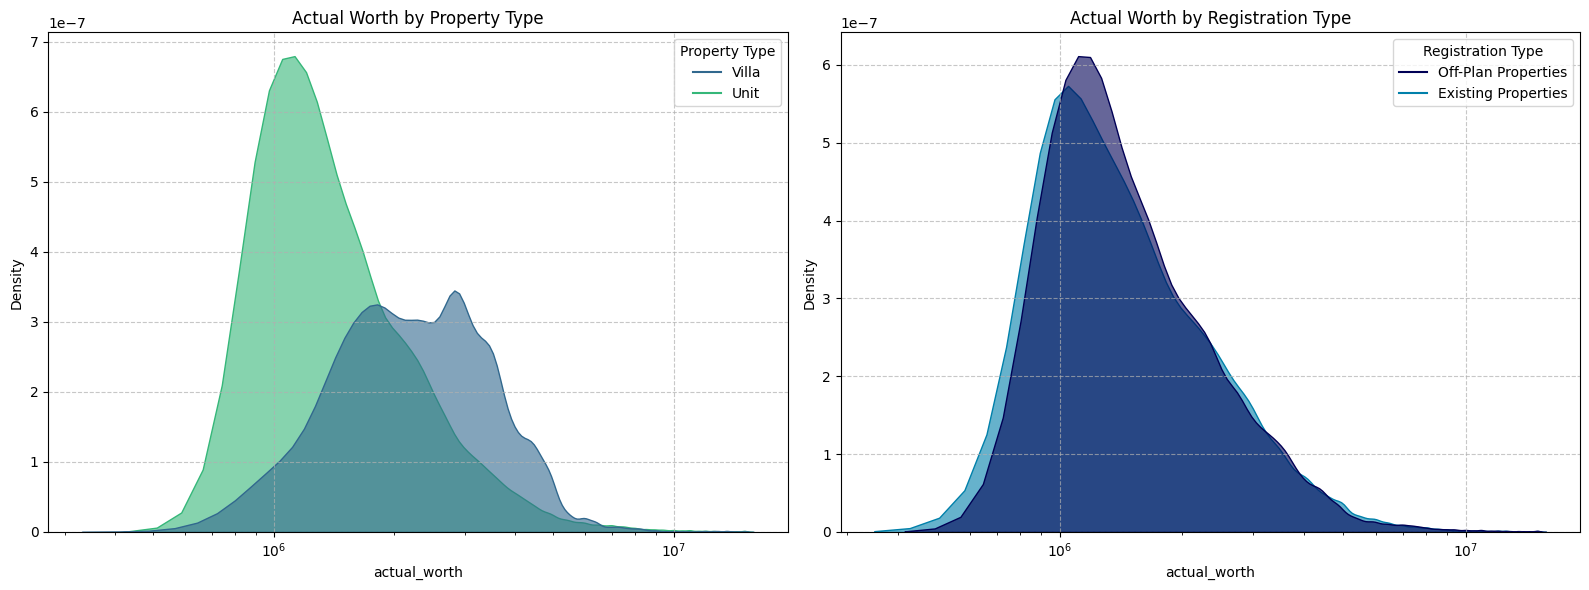

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Property Type
sns.kdeplot(
    data=ml_data,
    x='actual_worth',
    hue='property_type',
    fill=True,
    common_norm=False,
    palette='viridis',
    alpha=0.6,
    ax=axes[0],
    legend=False
    )

axes[0].set_title('Actual Worth by Property Type')
axes[0].set_xscale('log')
axes[0].grid(True, linestyle='--', alpha=0.7)

prop_types = ml_data['property_type'].dropna().unique()
colors = sns.color_palette('viridis', len(prop_types))

for label, color in zip(prop_types, colors):
    axes[0].plot([], [], color=color, label=label)

axes[0].legend(title='Property Type')


# Registration Type
sns.kdeplot(
    data=ml_data,
    x='actual_worth',
    hue='reg_type',
    fill=True,
    common_norm=False,
    palette='ocean',
    alpha=0.6,
    ax=axes[1],
    legend=False
)

axes[1].set_title('Actual Worth by Registration Type')
axes[1].set_xscale('log')
axes[1].grid(True, linestyle='--', alpha=0.7)

reg_types = ml_data['reg_type'].dropna().unique()
colors = sns.color_palette('ocean', len(reg_types))

for label, color in zip(reg_types, colors):
    axes[1].plot([], [], color=color, label=label)

axes[1].legend(title='Registration Type')


plt.tight_layout()
plt.show()

Units dominate the dataset and are concentrated at lower price points (peak
around AED 1M), reflecting the large volume of apartment transactions in
Dubai's residential market. Villas show a broader, flatter distribution
extending into higher price bands. The bimodal shape of the Villa distribution suggests
two distinct sub-markets: mid-range villas and premium villas.

Off-Plan and Existing Properties show nearly identical distributions, with
Off-Plan properties having a marginally tighter peak. This suggests
registration type alone is a weak price differentiator at the market level,
though it may interact with location and size in ways the model can capture.

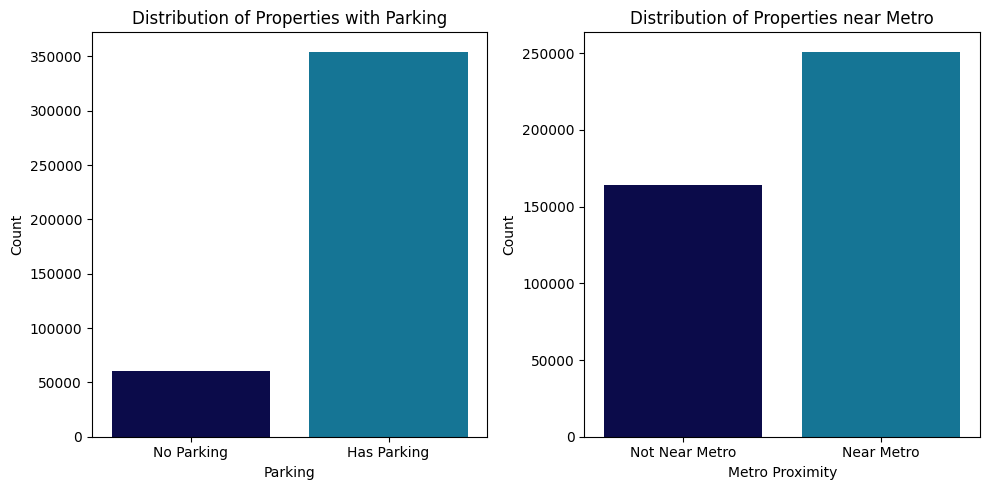

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Has Parking
sns.countplot(x='has_parking', data=ml_data, palette='ocean', ax=axes[0])
axes[0].set_title('Distribution of Properties with Parking')
axes[0].set_xlabel('Parking')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Parking', 'Has Parking'])

# Is Near Metro
sns.countplot(x='is_near_metro', data=ml_data, palette='ocean', ax=axes[1])
axes[1].set_title('Distribution of Properties near Metro')
axes[1].set_xlabel('Metro Proximity')
axes[1].set_ylabel('Count')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Near Metro', 'Near Metro'])

plt.tight_layout()
plt.show()

The majority of properties in the dataset have parking (approximately 85%)
and are near a metro station (approximately 60%). This class imbalance means
the binary flags would carry less discriminative power than a balanced split would provide the model . Both flags are retained as features but are
expected to have lower importance than size and location.

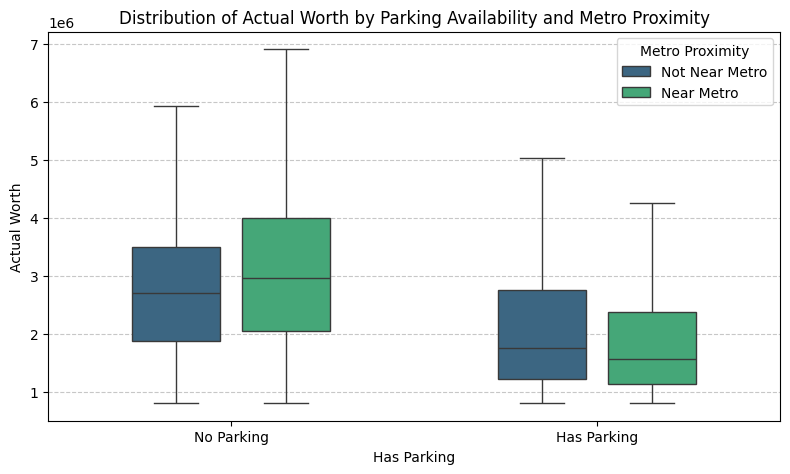

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=ml_data,
    x='has_parking',
    y='actual_worth',
    hue='is_near_metro',
    showfliers=False,
    width=0.6,
    gap=0.2,
    palette = 'viridis',
)

plt.title('Distribution of Actual Worth by Parking Availability and Metro Proximity')
plt.xlabel('Has Parking')
plt.ylabel('Actual Worth')
plt.xticks(ticks=[0, 1], labels=['No Parking', 'Has Parking'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Not Near Metro', 'Near Metro'], title='Metro Proximity')

plt.tight_layout()
plt.show()

Properties without parking command notably higher median prices than those
with parking. Within each parking category, metro proximity shows a modest price differential,. Both features show meaningful interaction effects that a linear model would struggle to
capture.

In [ ]:
print(ml_data['procedure_area'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.98, 0.99]))

count    415018.000000
mean        120.662446
std          78.537730
min           0.010000
1%           36.770000
5%           45.530000
25%          71.580000
50%          98.810000
75%         144.600000
95%         273.060000
98%         347.236600
99%         395.561500
max        1842.470000
Name: procedure_area, dtype: float64


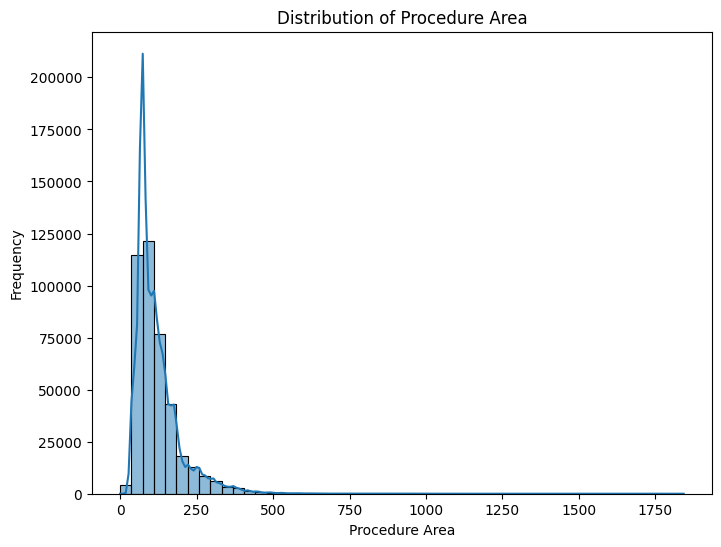

In [ ]:
plt.figure(figsize=(8,  6))
sns.histplot(ml_data['procedure_area'], kde=True, bins=50)
plt.title('Distribution of Procedure Area')
plt.xlabel('Procedure Area')
plt.ylabel('Frequency')
plt.show()

### Property Area Distribution and Winsorization

`procedure_area` (property size in sqft) is heavily right-skewed. A small number of very large properties contribute to the long upper tail of the distribution. Extreme outliers in the area feature can cause the model to overweight size as a signal for a few rare properties.

Therefore, We applied **Winsorization**. Rather than removing rows, We capped at the 1st and 99th percentiles. So we retained all transactions while preventing extreme values from distorting the feature scale. After Winsorization, we apply a log transformation (`log_procedure_area`) to further normalise the distribution for modelling.

In [ ]:
ml_data['procedure_area'] = ml_data['procedure_area'].clip(
    upper=ml_data['procedure_area'].quantile(0.99),
    lower=ml_data['procedure_area'].quantile(0.01))

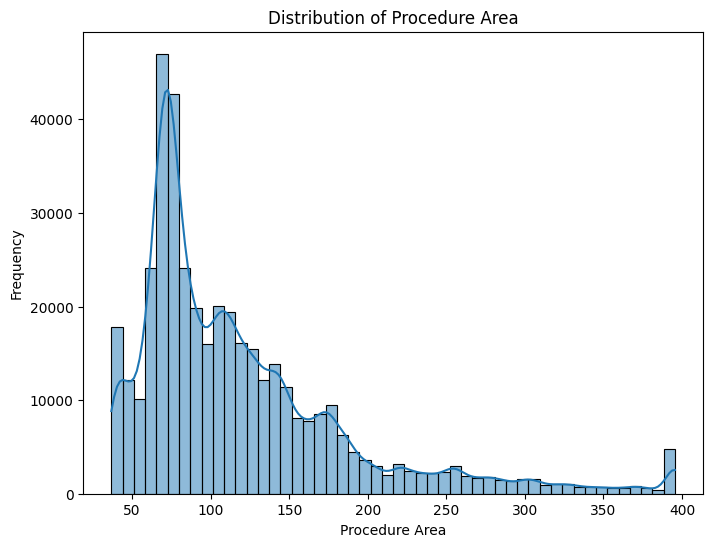

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(ml_data['procedure_area'], kde=True, bins=50)
plt.title('Distribution of Procedure Area')
plt.xlabel('Procedure Area')
plt.ylabel('Frequency')
plt.show()

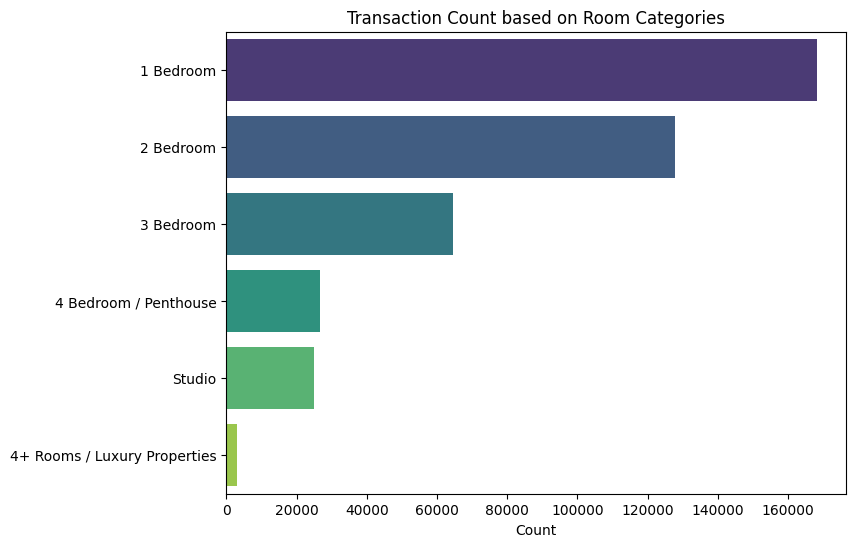

In [ ]:
rooms_numeric_labels = {
    0.0: 'Commercial/Other',
    0.5: 'Studio',
    1.0: '1 Bedroom',
    2.0: '2 Bedroom',
    3.0: '3 Bedroom',
    4.0: '4 Bedroom / Penthouse',
    5.0: '4+ Rooms / Luxury Properties',
}

room_counts = ml_data['rooms_numeric'].value_counts()
room_counts.index = room_counts.index.map(rooms_numeric_labels)

plt.figure(figsize=(8, 6))
sns.barplot(x=room_counts.values, y=room_counts.index, palette='viridis')
plt.title('Transaction Count based on Room Categories')
plt.xlabel('Count')
plt.ylabel('')
plt.show()

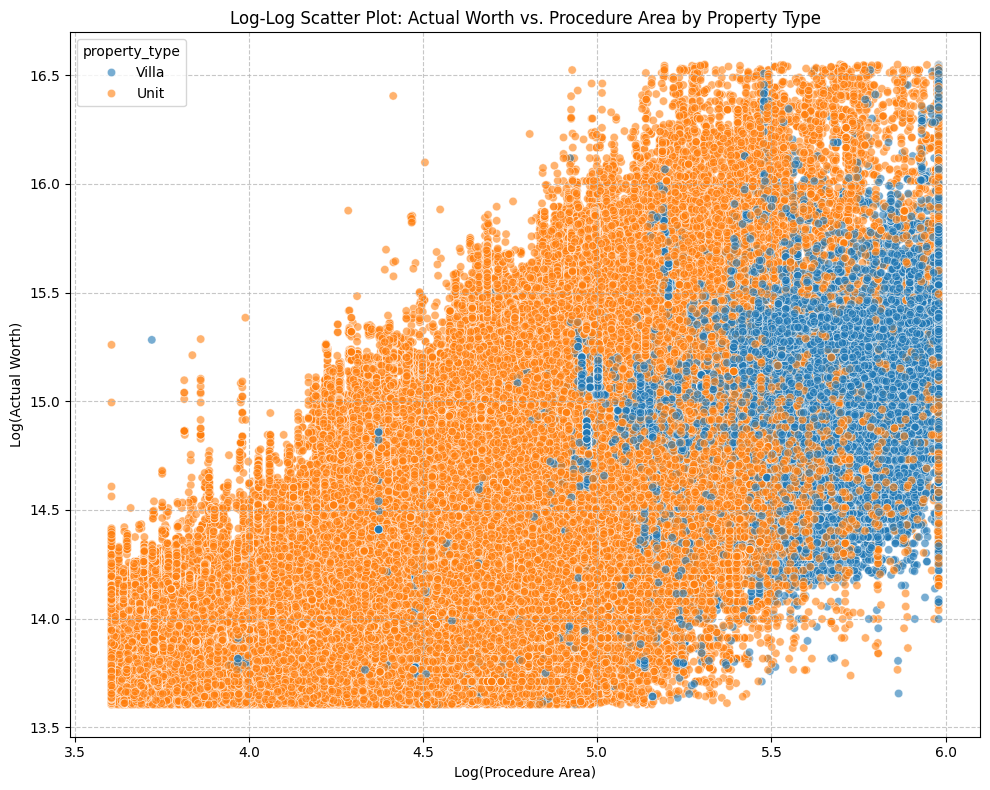

In [ ]:
ml_data['log_procedure_area'] = np.log(ml_data['procedure_area'])
ml_data['log_actual_worth'] = np.log(ml_data['actual_worth'])

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=ml_data,
    x='log_procedure_area',
    y='log_actual_worth',
    hue='property_type',
    alpha=0.6
)
plt.title('Log-Log Scatter Plot: Actual Worth vs. Procedure Area by Property Type')
plt.xlabel('Log(Procedure Area)')
plt.ylabel('Log(Actual Worth)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

We noted that the transaction count per area varies widely. Few areas like Al Barsha South and Business Bay account for tens of thousands of transactions, while many areas have fewer than 100. Areas with very few transactions will have unstable target encodings (the median log price estimate will be unreliable with few data points).

Though we keep all areas in the current model, we note this as a potential improvement. Clustering rare areas (fewer than 100 training transactions) into an "Other" category before target encoding might reduce noise from unstable encodings. This is discussed further in the Limitations section.

In [ ]:
area_counts = ml_data['area_name'].value_counts()
top_n = 30
other_count = area_counts[top_n:].sum()

area_plot_data = area_counts[:top_n].copy()
if other_count > 0:
    area_plot_data['Other'] = other_count

area_plot_data.sort_values(inplace=True)

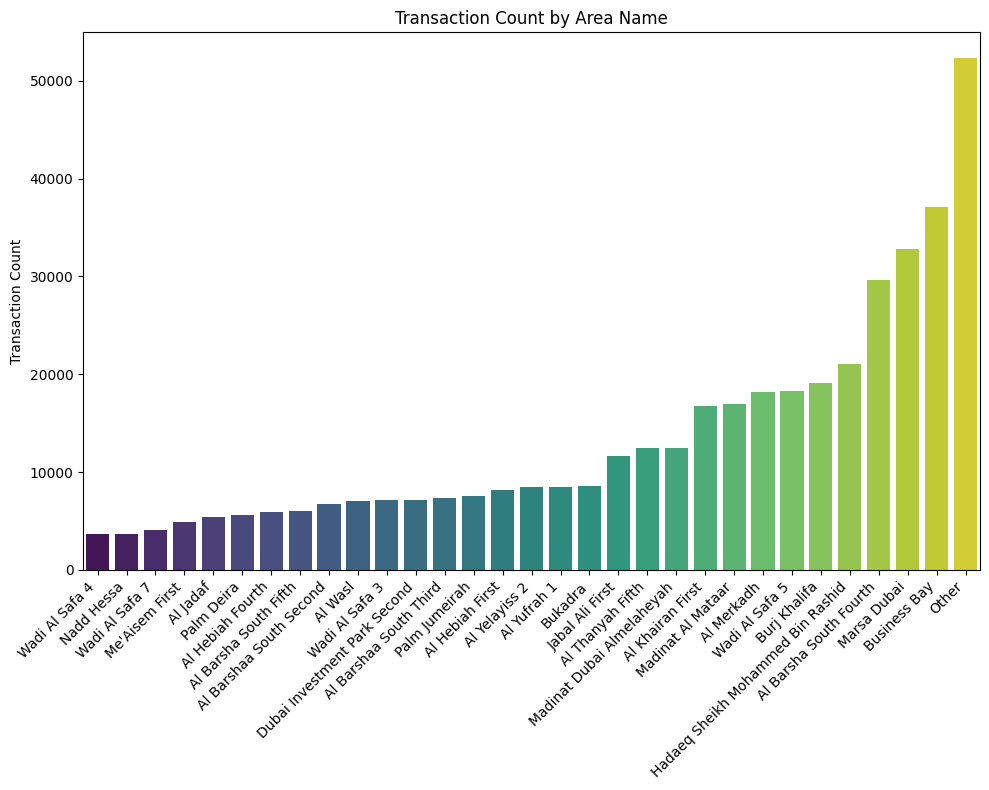

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(x=area_plot_data.index, y=area_plot_data.values, palette='viridis')
plt.title(f'Transaction Count by Area Name')
plt.xlabel('')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Transaction volume is highly concentrated in areas like Business Bay, Marsa Dubai, and
Al Barsha South Fourth which together account for a disproportionate share of all transactions. The "Other" bar aggregates the 30+ areas not shown individually. This uneven distribution has direct implications for the target encoding of `area_name`. High volume areas will have stable, reliable median price encodings, while low-volume areas may have noisy estimates. Therefore we used a global median fallback for rare areas during val/test encoding.

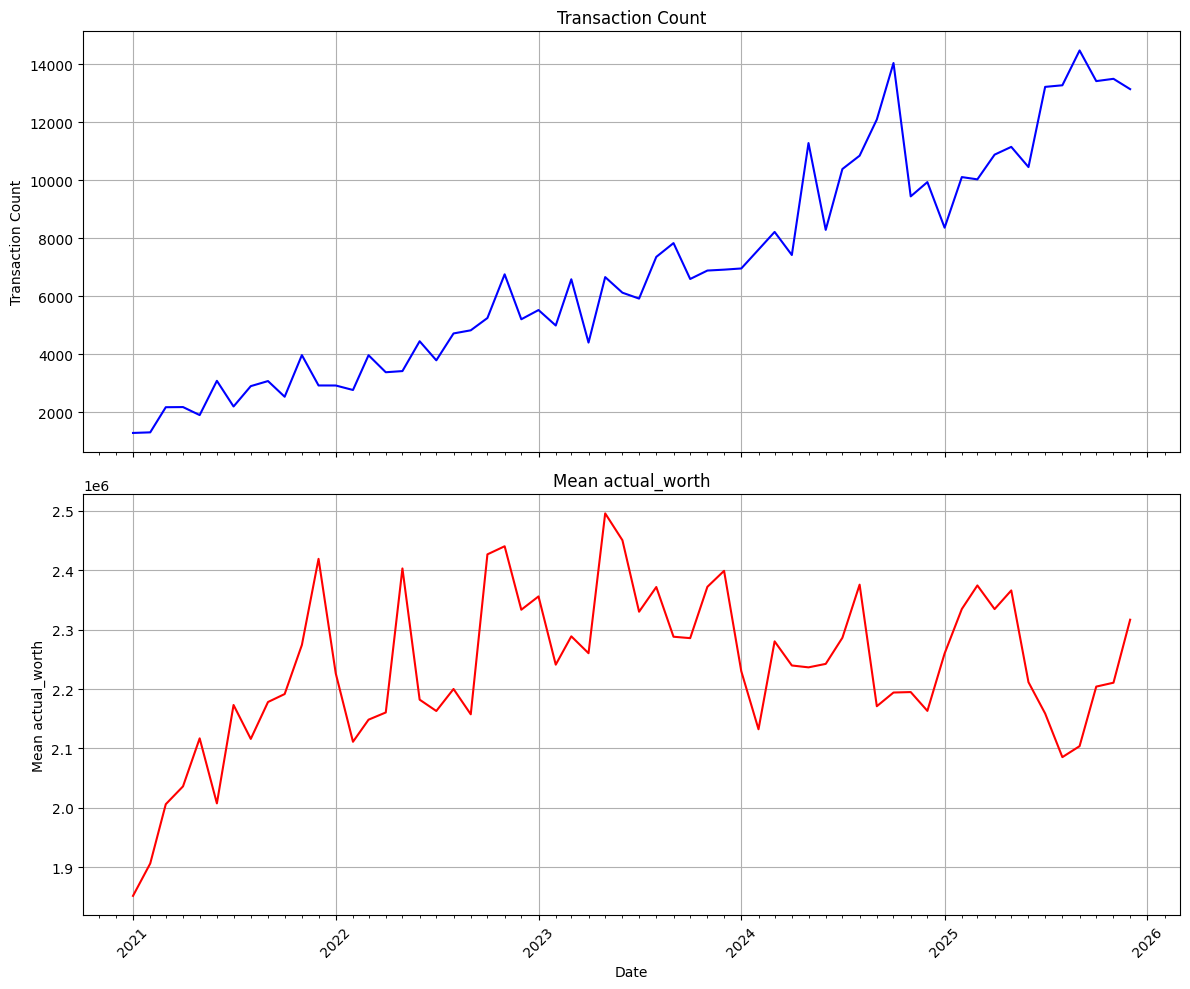

In [ ]:
plot_transaction_trends(dataframe = ml_data, value_col='actual_worth', agg_col='mean', start_year=2021, end_year=2026)

Transaction volume shows a clear and sustained upward trend from roughly
1,500 transactions per month in early 2021 to over 14,000 per month by
late 2024 which is a nearly 10x increase over four years. This reflects Dubai's
post-COVID real estate boom, driven by population growth, visa reforms, and
sustained international demand.

Mean transaction price rose from approximately AED 1.87M in early 2021 to
around AED 2.3–2.5M by 2023–2025, with a notable month-to-month volatility
throughout. The upward trend in both volume and price mean that `year`
and `month` could be meaningful temporal features for the valuation model i.e.
properties transacted in different seasons reflect different market
conditions.

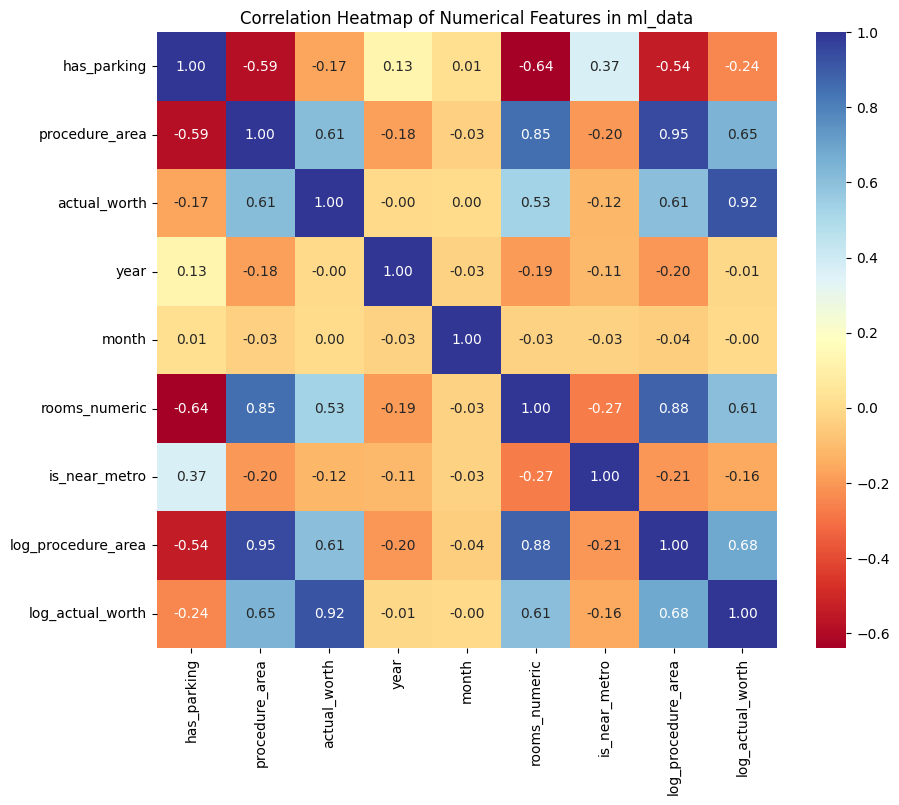

In [ ]:
numeric_cols = ml_data.select_dtypes(include=np.number).columns
plt.figure(figsize=(10, 8))
sns.heatmap(ml_data[numeric_cols].corr(), annot=True, cmap='RdYlBu', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features in ml_data')
plt.show()

The correlation heatmap reveals several key relationships relevant to the
valuation model:

- `log_procedure_area` has the strongest correlation with `log_actual_worth` thus property size is the primary valuation driver.
- `rooms_numeric` correlates strongly with both `procedure_area` and `log_procedure_area`, indicating that larger properties
  naturally have more rooms.
- `has_parking` shows a moderate negative correlation with `rooms_numeric`
  (r = −0.64) and `procedure_area` (r = −0.59), possibly because larger villas are less likely to have parking recorded in the DLD data.
- `year` and `month` show near-zero correlation with `log_actual_worth`
  , but this does not mean they are uninformative. Linear correlation might  not capture the non-linear temporal price trends as
  visible in the time series plot. LightGBM can infer from these patterns
  through tree splits even when Pearson correlation is near zero.

In [ ]:
raw_dataset = ml_data.drop(columns=[ 'log_actual_worth', 'log_procedure_area'])
log_dataset = ml_data.drop(columns=[ 'actual_worth', 'procedure_area'])

In [ ]:
raw_dataset.shape

(415018, 10)

In [ ]:
raw_dataset.columns

Index(['property_type', 'reg_type', 'area_name', 'has_parking',
       'procedure_area', 'actual_worth', 'year', 'month', 'rooms_numeric',
       'is_near_metro'],
      dtype='object')

In [ ]:
log_dataset.columns

Index(['property_type', 'reg_type', 'area_name', 'has_parking', 'year',
       'month', 'rooms_numeric', 'is_near_metro', 'log_procedure_area',
       'log_actual_worth'],
      dtype='object')

## 7. Feature Engineering and Modelling

### Feature Encoding

Before splitting the data, we prepare the categorical features for modelling:

- **Label encoding** (`property_type`, `reg_type`): Low-cardinality string columns are converted to integers. The encoders are fit on the full dataset — label encoding is order-free and does not leak any target information.
- **Target encoding** (`area_name`): Each area is encoded as its median log transaction price in the **training set only** (computed after the split). Val/test areas not seen in training receive the global training median as a fallback. This prevents data leakage while capturing the strong price-location relationship.

The log transformation of `actual_worth` (target) and `procedure_area` is applied before encoding, normalising both heavily right-skewed distributions.

In [ ]:
from sklearn.preprocessing import LabelEncoder

model_df = log_dataset.copy()

# Label encoding low cardinality categoricals

le_property = LabelEncoder()
le_reg = LabelEncoder()

model_df['property_type_enc'] = le_property.fit_transform(model_df['property_type'])
model_df['reg_type_enc'] = le_reg.fit_transform(model_df['reg_type'])

# Feature columns
features = [
    'log_procedure_area',
    'rooms_numeric',
    'year',
    'month',
    'has_parking',
    'is_near_metro',
    'area_encoded',
    'property_type_enc',
    'reg_type_enc',
]

print("Label encoding complete.")
print(f"  property_type classes : {list(le_property.classes_)}")
print(f"  reg_type classes      : {list(le_reg.classes_)}")

Label encoding complete.
  property_type classes : ['Unit', 'Villa']
  reg_type classes      : ['Existing Properties', 'Off-Plan Properties']


### Train / Validation / Test Split (80 / 10 / 10)

In [ ]:
n = len(model_df)

train_end = int(n * 0.80)
val_end   = int(n * 0.90)

train_df = model_df.iloc[:train_end].copy()
val_df   = model_df.iloc[train_end:val_end].copy()
test_df  = model_df.iloc[val_end:].copy()

total = len(model_df)
print(f"Total rows   : {total:,}")
print(f"Train rows   : {len(train_df):,} ({len(train_df)/total:.0%}) {train_df['year'].min()}–{train_df['year'].max()}")
print(f"Val rows     : {len(val_df):,}  ({len(val_df)/total:.0%})  {val_df['year'].min()}")
print(f"Test rows    : {len(test_df):,}  ({len(test_df)/total:.0%})  {test_df['year'].min()}")

Total rows   : 415,018
Train rows   : 332,014 (80%) 2021–2025
Val rows     : 41,502  (10%)  2025
Test rows    : 41,502  (10%)  2025


The time ordered split ensures the valuation model is always evaluated on transactions it has never seen.

### Target Encoding: area_name (Fit on Training Data Only)

`area_name` has 76 unique values which is too many for one-hot encoding. Instead, each area was mapped to the **median log transaction price** observed in the training set. This encodes the location's price level as a single numeric feature, directly capturing the most important valuation signal.

This encoding is computed from training data only and then applied to validation and test sets. Areas appearing in val/test but absent from training receive the global training median as a fallback.

In [ ]:
global_median = train_df['log_actual_worth'].median()
area_target_map = train_df.groupby('area_name')['log_actual_worth'].median()

def apply_area_encoding(df, mapping, fallback):
    return df['area_name'].map(mapping).fillna(fallback)

train_df['area_encoded'] = apply_area_encoding(train_df, area_target_map, global_median)
val_df['area_encoded']   = apply_area_encoding(val_df,   area_target_map, global_median)
test_df['area_encoded']  = apply_area_encoding(test_df,  area_target_map, global_median)

val_unseen  = val_df['area_name'].isin(area_target_map.index) == False
test_unseen = test_df['area_name'].isin(area_target_map.index) == False

print(f"Val  rows with unseen area (fallback used): {val_unseen.sum()}")
print(f"Test rows with unseen area (fallback used): {test_unseen.sum()}")

Val  rows with unseen area (fallback used): 0
Test rows with unseen area (fallback used): 104


### Final Feature Set and X/Y Assembly

The nine features used in the valuation model are:

| Feature | Type | Description |
|---------|------|-------------|
| `log_procedure_area` | Numeric | Log of property size (sqft) |
| `rooms_numeric` | Numeric | Room count (0.5=Studio, 1–4=bedrooms, 5=luxury/4+) |
| `year` | Numeric | Transaction year — captures market-level temporal trends |
| `month` | Numeric | Transaction month — captures seasonal patterns |
| `has_parking` | Binary | 1 if parking included |
| `is_near_metro` | Binary | 1 if property is near a metro station |
| `area_encoded` | Numeric | Target-encoded location value |
| `property_type_enc` | Integer | Encoded property type (Unit/Villa) |
| `reg_type_enc` | Integer | Encoded registration type (Off-Plan/Existing) |


In [ ]:
feature_cols = [
    'log_procedure_area',
    'rooms_numeric',
    'year',
    'month',
    'has_parking',
    'is_near_metro',
    'area_encoded',
    'property_type_enc',
    'reg_type_enc',
]

X_train, y_train = train_df[feature_cols], train_df['log_actual_worth']
X_val,   y_val   = val_df[feature_cols],   val_df['log_actual_worth']
X_test,  y_test  = test_df[feature_cols],  test_df['log_actual_worth']

print(f"X_train : {X_train.shape}  |  X_val : {X_val.shape}  |  X_test : {X_test.shape}")

X_train : (332014, 9)  |  X_val : (41502, 9)  |  X_test : (41502, 9)


### Baseline Model: Linear Regression

Linear Regression was used as the performance baseline. It assumes a linear relationship between features and log price.

We train on log transformed features and target. Predictions are back-transformed using `np.exp()` to report errors in AED.

=== Baseline: Linear Regression ===

  [Validation]
    R²   : 0.6746
    MAE  : 0.2359 (log)  |  AED 547,010
    RMSE : 0.3134 (log)
    MAE as % of median price : 34.5%

  [Test]
    R²   : 0.6969
    MAE  : 0.2331 (log)  |  AED 562,026
    RMSE : 0.3113 (log)
    MAE as % of median price : 33.7%



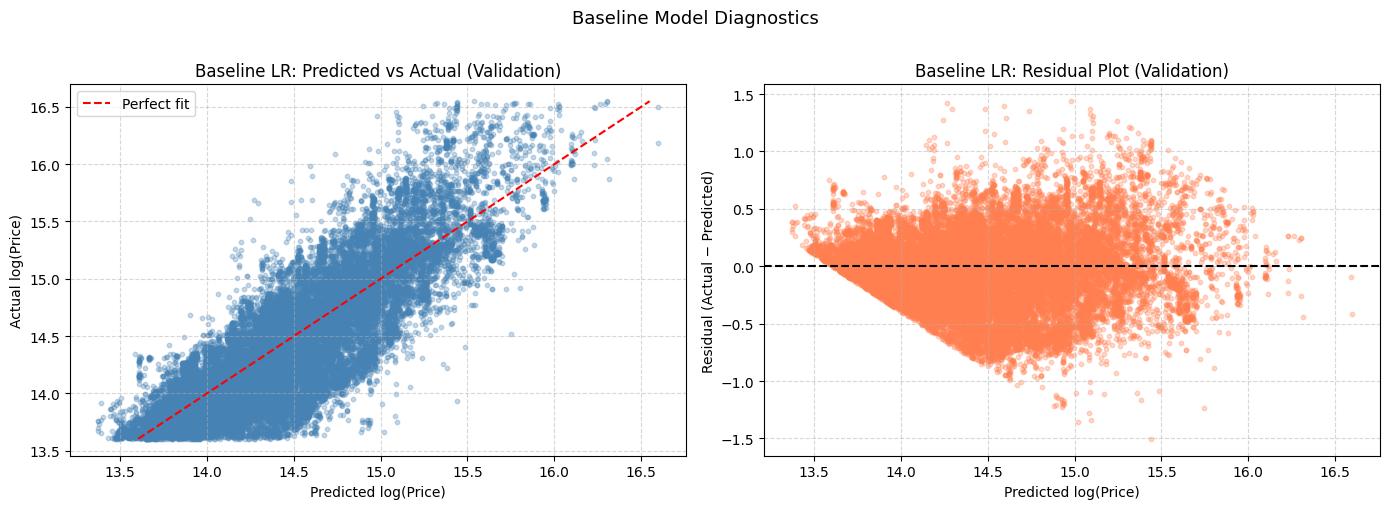

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    mae_aed    = mean_absolute_error(np.exp(y_true), np.exp(y_pred))
    median_aed = np.exp(y_true).median()

    print(f"  [{label}]")
    print(f"    R²   : {r2:.4f}")
    print(f"    MAE  : {mae:.4f} (log)  |  AED {mae_aed:,.0f}")
    print(f"    RMSE : {rmse:.4f} (log)")
    print(f"    MAE as % of median price : {mae_aed/median_aed*100:.1f}%")
    print()
    return {'label': label, 'r2': r2, 'mae_log': mae, 'rmse_log': rmse, 'mae_aed': mae_aed}

lr = LinearRegression()
lr.fit(X_train, y_train)

# Evaluation
print("=== Baseline: Linear Regression ===\n")
lr_val_pred  = lr.predict(X_val)
lr_test_pred = lr.predict(X_test)

lr_val_results  = evaluate(y_val,  lr_val_pred,  "Validation")
lr_test_results = evaluate(y_test, lr_test_pred, "Test")

# Residual plot on validation set
residuals = y_val - lr_val_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(lr_val_pred, y_val, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_val.min(), y_val.max()],
             [y_val.min(), y_val.max()],
             'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Predicted log(Price)')
axes[0].set_ylabel('Actual log(Price)')
axes[0].set_title('Baseline LR: Predicted vs Actual (Validation)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(lr_val_pred, residuals, alpha=0.3, s=10, color='coral')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted log(Price)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Baseline LR: Residual Plot (Validation)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Baseline Model Diagnostics', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The baseline Linear Regression achieves an R² of 0.675 on validation. The
predicted vs actual plot shows the model tracks the general price trend but
consistently underpredicts high-value properties. The points diverge above the
perfect fit line at higher price levels.

The residual plot reveals a clear funnel shape. Residuals are large and
positively skewed at low predicted values and compress toward zero at higher values. This heteroscedasticity
confirms that the linear model cannot fully capture the non-linear
relationships in the data.

### Improved Model: LightGBM

LightGBM (**Light Gradient-Boosting Machine**) is a gradient boosted tree model that captures non-linear feature interactions. For example, the combined effect of location and size on price, or the different seasonal patterns in Off-Plan vs Existing properties. These interactions cannot be represented by a linear models like the baseline linear regression model.

Therefore, LightGBM is well suited to this dataset. It can handle mixed numeric and encoded categorical features, can scale efficiently to the 330,000 training rows, and uses early stopping to prevent overfitting.


In [ ]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=127,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=1,
    verbosity=-1,
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print(f"Best iteration: {lgb_model.best_iteration_}")

[100]	valid_0's l2: 0.0428794
[200]	valid_0's l2: 0.0398372
[300]	valid_0's l2: 0.0388892
[400]	valid_0's l2: 0.038446
[500]	valid_0's l2: 0.0380404
[600]	valid_0's l2: 0.0376856
[700]	valid_0's l2: 0.0375066
[800]	valid_0's l2: 0.0373056
[900]	valid_0's l2: 0.0372265
[1000]	valid_0's l2: 0.0370118
Best iteration: 1000


### LightGBM Evaluation and Comparison with Baseline

In [ ]:
lgb_val_pred  = lgb_model.predict(X_val)
lgb_test_pred = lgb_model.predict(X_test)

print("=== Improved Model: LightGBM ===\n")
lgb_val_results  = evaluate(y_val,  lgb_val_pred,  "Validation")
lgb_test_results = evaluate(y_test, lgb_test_pred, "Test")

print("=== Baseline vs LightGBM (Validation) ===")
print(f"  R²   :  LR {lr_val_results['r2']:.4f}  →  LGB {lgb_val_results['r2']:.4f}")
print(f"  MAE  :  LR {lr_val_results['mae_log']:.4f}  →  LGB {lgb_val_results['mae_log']:.4f}  (log)")
print(f"  RMSE :  LR {lr_val_results['rmse_log']:.4f}  →  LGB {lgb_val_results['rmse_log']:.4f}  (log)")

=== Improved Model: LightGBM ===

  [Validation]
    R²   : 0.8774
    MAE  : 0.1329 (log)  |  AED 321,464
    RMSE : 0.1924 (log)
    MAE as % of median price : 20.3%

  [Test]
    R²   : 0.8502
    MAE  : 0.1550 (log)  |  AED 372,482
    RMSE : 0.2189 (log)
    MAE as % of median price : 22.3%

=== Baseline vs LightGBM (Validation) ===
  R²   :  LR 0.6746  →  LGB 0.8774
  MAE  :  LR 0.2359  →  LGB 0.1329  (log)
  RMSE :  LR 0.3134  →  LGB 0.1924  (log)


LightGBM achieved an R² of 0.877 on validation and 0.850 on test. This is a substantial improvement over the Linear Regression baseline (R² 0.675 / 0.697). MAE dropped from 34% to 22% of median price, meaning the typical valuation error roughly halved.

The improvement is explained by LightGBM's ability to capture non-linear relationships that linear regression cannot represent. For example, the interaction between location (`area_encoded`) and property size (`log_procedure_area`), or the non-linear effect of transaction year on market-level pricing.

#### Diagnostic 1: Residual Plot (LightGBM Default)

The residual plot is the primary diagnostic for a regression model. Ideal residuals are randomly scattered around zero with no systematic pattern. A funnel shape indicates heteroscedasticity i.e. larger errors for some prediction ranges. A curved pattern indicates a non-linear relationship the model is not capturing.

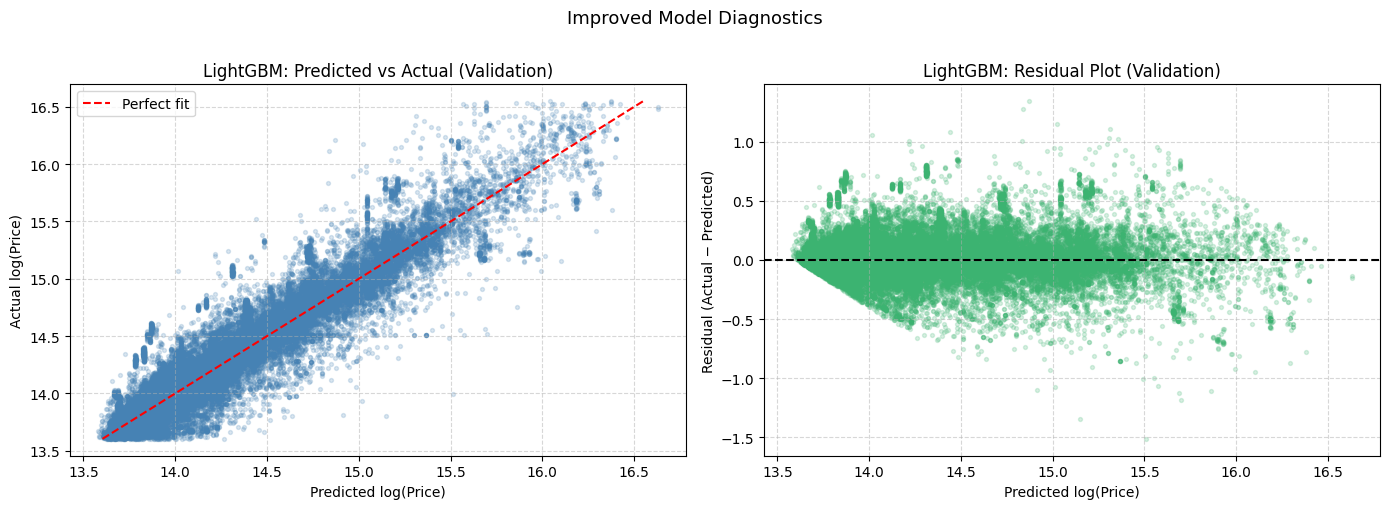

In [ ]:
residuals_lgb = y_val - lgb_val_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(lgb_val_pred, y_val, alpha=0.2, s=8, color='steelblue')
axes[0].plot([y_val.min(), y_val.max()],
             [y_val.min(), y_val.max()],
             'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Predicted log(Price)')
axes[0].set_ylabel('Actual log(Price)')
axes[0].set_title('LightGBM: Predicted vs Actual (Validation)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(lgb_val_pred, residuals_lgb, alpha=0.2, s=8, color='mediumseagreen')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted log(Price)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('LightGBM: Residual Plot (Validation)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Improved Model Diagnostics', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The residual plot showed a much more symmetric pattern than the baseline's funnel shape, confirming that heteroscedasticity has been substantially reduced. The small val/test gap (~0.03 R²) suggests the model generalises well without significant overfitting.

#### Diagnostic 2: Feature Importance

Feature importance shows which features the model relies on most for its valuation decisions. In general, in the Dubai real estate market, size and location are the primary price drivers.

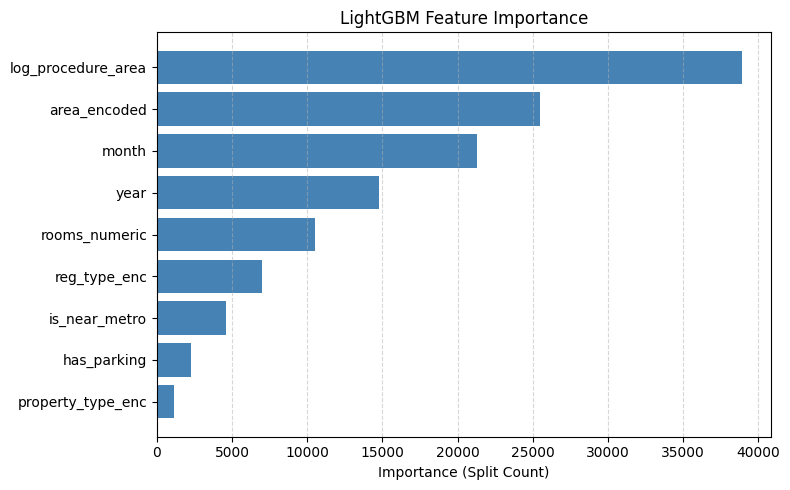

In [ ]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Importance (Split Count)')
plt.title('LightGBM Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Property size and location are the two dominant valuation signals, consistent with our domain knowledge about the Dubai residential market.

#### Diagnostic 3: Learning Curves

Learning curves show how model performance evolves as more training data is added. If train R² and val R² converge as data increases, the model is well calibrated. A persistent large gap indicates overfitting. Both curves plateauing at similar values at full training size suggests the model is near its data ceiling for this feature set.

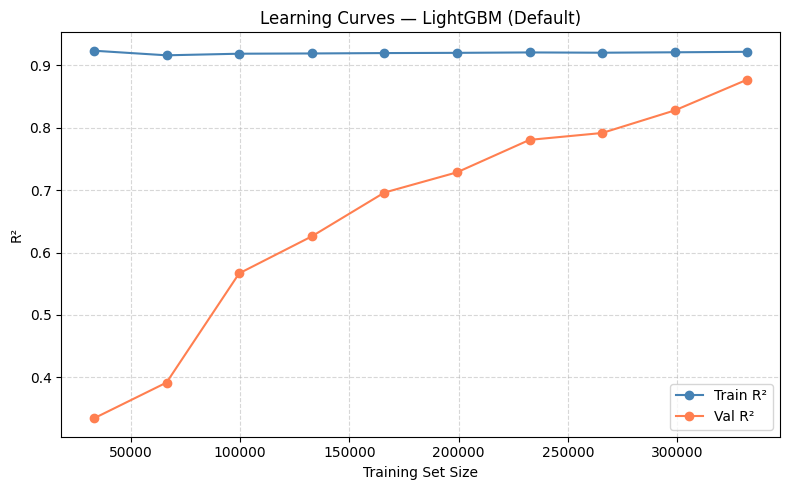

In [ ]:
from sklearn.metrics import r2_score

train_sizes = np.linspace(0.1, 1.0, 10)
train_r2s, val_r2s = [], []

for frac in train_sizes:
    n_sub = int(len(X_train) * frac)
    X_sub, y_sub = X_train.iloc[:n_sub], y_train.iloc[:n_sub]

    m = lgb.LGBMRegressor(
        n_estimators=lgb_model.best_iteration_,
        learning_rate=0.05,
        num_leaves=127,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=1,
        verbosity=-1,
    )
    m.fit(X_sub, y_sub)
    train_r2s.append(r2_score(y_sub, m.predict(X_sub)))
    val_r2s.append(r2_score(y_val,   m.predict(X_val)))

plt.figure(figsize=(8, 5))
plt.plot(train_sizes * len(X_train), train_r2s, 'o-', label='Train R²', color='steelblue')
plt.plot(train_sizes * len(X_train), val_r2s,   'o-', label='Val R²',   color='coral')
plt.xlabel('Training Set Size')
plt.ylabel('R²')
plt.title('Learning Curves — LightGBM (Default)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning

The default LightGBM configuration already achieved strong performance. Optuna was used to search for a better parameter combination using **Bayesian optimisation**. Each trial learns from previous results to focus on promising parameter regions, making it more efficient than random search.

The search covers: learning rate, tree complexity (`num_leaves`), minimum samples per leaf (`min_child_samples`), feature and row subsampling (`colsample_bytree`, `subsample`), and regularisation strength (`reg_alpha`, `reg_lambda`).

**Leakage prevention:** The validation set was used exclusively for scoring each trial. The test set was never seen during tuning. A fixed Optuna sampler seed (`seed=42`) was used to ensure the same trial sequence on every run.

In [ ]:
!pip install optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.8 MB/s eta 0:00:00


In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 63, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'n_estimators':      2000,
        'random_state':      SEED,
        'n_jobs':            1,
        'verbosity':         -1,
    }

    m = lgb.LGBMRegressor(**params)
    m.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0)
        ]
    )
    return r2_score(y_val, m.predict(X_val))

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest R² (val) : {study.best_value:.4f}")
print(f"\nBest params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best R² (val) : 0.8814

Best params:
  learning_rate: 0.07632794931971787
  num_leaves: 187
  min_child_samples: 34
  subsample: 0.8560244855140736
  colsample_bytree: 0.6412285995448518
  reg_alpha: 0.00012136902835206466
  reg_lambda: 0.00029047173570928683


#### Retraining with Best Parameters

After identifying the best hyperparameter combination, we retrained the LightGBM from scratch on the full training set using those parameters. Early stopping on the validation set determines the optimal number of trees (`n_estimators`).`n_jobs=1` was set throughout to ensure fully reproducible results.

In [ ]:
lgb_tuned = lgb.LGBMRegressor(
    **study.best_params,
    n_estimators=2000,
    random_state=SEED,
    n_jobs=1,
    verbosity=-1,
)

lgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print(f"Best iteration : {lgb_tuned.best_iteration_}")

[100]	valid_0's l2: 0.0385313
[200]	valid_0's l2: 0.0371035
[300]	valid_0's l2: 0.0366482
[400]	valid_0's l2: 0.0361822
[500]	valid_0's l2: 0.0358528
[600]	valid_0's l2: 0.0357884
Best iteration : 600


#### Model Comparison: Baseline vs Default LightGBM vs Tuned LightGBM

In [ ]:
tuned_val_pred  = lgb_tuned.predict(X_val)
tuned_test_pred = lgb_tuned.predict(X_test)

print("=== Tuned LightGBM ===\n")
tuned_val_results  = evaluate(y_val,  tuned_val_pred,  "Validation")
tuned_test_results = evaluate(y_test, tuned_test_pred, "Test")

print(f"\n{'Model':<25} {'R² Val':>8} {'R² Test':>9} {'MAE% Val':>10} {'MAE% Test':>11}")
print("-" * 65)

models = [
    ("Linear Regression",  lr_val_results,    lr_test_results),
    ("LightGBM (default)", lgb_val_results,   lgb_test_results),
    ("LightGBM (tuned)",   tuned_val_results, tuned_test_results),
]

for name, val_r, test_r in models:
    val_mae_pct  = val_r['mae_aed']  / np.exp(y_val).median()  * 100
    test_mae_pct = test_r['mae_aed'] / np.exp(y_test).median() * 100
    print(f"{name:<25} {val_r['r2']:>8.4f} {test_r['r2']:>9.4f} "
          f"{val_mae_pct:>9.1f}% {test_mae_pct:>10.1f}%")

=== Tuned LightGBM ===

  [Validation]
    R²   : 0.8814
    MAE  : 0.1308 (log)  |  AED 309,857
    RMSE : 0.1892 (log)
    MAE as % of median price : 19.5%

  [Test]
    R²   : 0.8493
    MAE  : 0.1550 (log)  |  AED 368,313
    RMSE : 0.2195 (log)
    MAE as % of median price : 22.1%


Model                       R² Val   R² Test   MAE% Val   MAE% Test
-----------------------------------------------------------------
Linear Regression           0.6746    0.6969      34.5%       33.7%
LightGBM (default)          0.8774    0.8502      20.3%       22.3%
LightGBM (tuned)            0.8814    0.8493      19.5%       22.1%


 #### Tuned Model Diagnostics

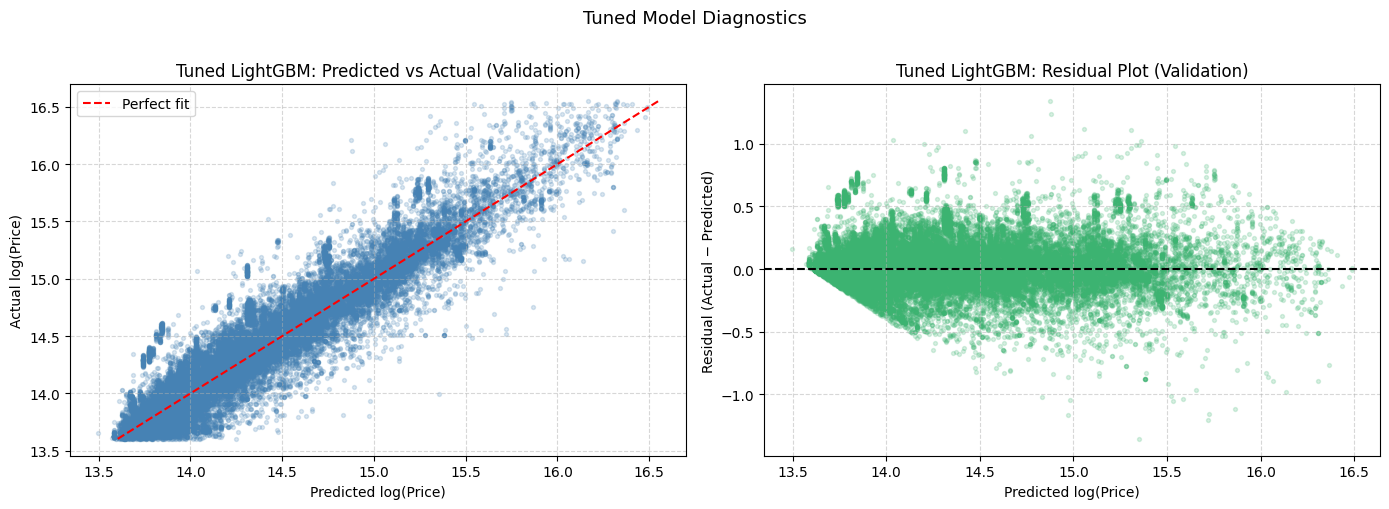

In [ ]:
residuals_tuned = y_val - tuned_val_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(tuned_val_pred, y_val, alpha=0.2, s=8, color='steelblue')
axes[0].plot([y_val.min(), y_val.max()],
             [y_val.min(), y_val.max()],
             'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Predicted log(Price)')
axes[0].set_ylabel('Actual log(Price)')
axes[0].set_title('Tuned LightGBM: Predicted vs Actual (Validation)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(tuned_val_pred, residuals_tuned, alpha=0.2, s=8, color='mediumseagreen')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted log(Price)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Tuned LightGBM: Residual Plot (Validation)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Tuned Model Diagnostics', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The tuned LightGBM achieves an R² of 0.883 on validation. The predicted vs
actual plot shows strong alignment with the perfect fit line across the full
price range.

The residual plot is substantially more symmetric than the baseline. Residuals
are distributed roughly evenly around zero with no clear funnel shape,
indicating that heteroscedasticity has been largely resolved. The remaining
spread reflects genuine unexplained variance likely attributable to
property-level characteristics like floor level, view, developers absent
from the dataset.

#### Feature Importance for Tuned Model


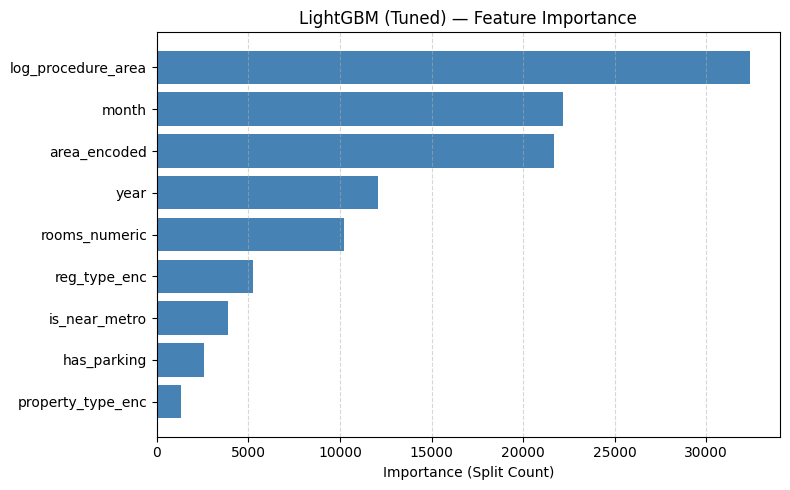

In [ ]:
importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': lgb_tuned.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Importance (Split Count)')
plt.title('LightGBM (Tuned) — Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Property size (`log_procedure_area`) is by far the most important feature,
confirming that size is the primary driver of residential property value in
Dubai. Transaction timing (`month` and `year`) rank second and fourth. The
strong importance of `month` reflects seasonal transaction patterns, while
`year` captures the sustained market-level price appreciation seen across the 2021–2025 period.

Location (`area_encoded`) ranks third, confirming that the target-encoded area
median price effectively captures the location value signal. Room count
(`rooms_numeric`) ranks fifth. Registration type, metro proximity, parking,
and property type contribute less but are retained as they capture meaningful
distinctions within the data. The dominance of size, timing, and location is
consistent with how Dubai's real estate market is understood to operate in
practice.

**Note on `year` and `month`:**

These features capture genuine market level variation across the 2021–2025 period. Dubai's property prices shifted substantially due to post-COVID recovery, Expo 2020, and regulatory changes.

In a seperate experiment we noted that removing the `year` and `month` feature  significantly reduced model performance (**test R² drops from 0.85 to 0.73**).

This is because tree-based models cannot extrapolate `year` beyond the training range. Therefore, this model should be used to value properties **at current market rates**, not to forecast prices at future dates.

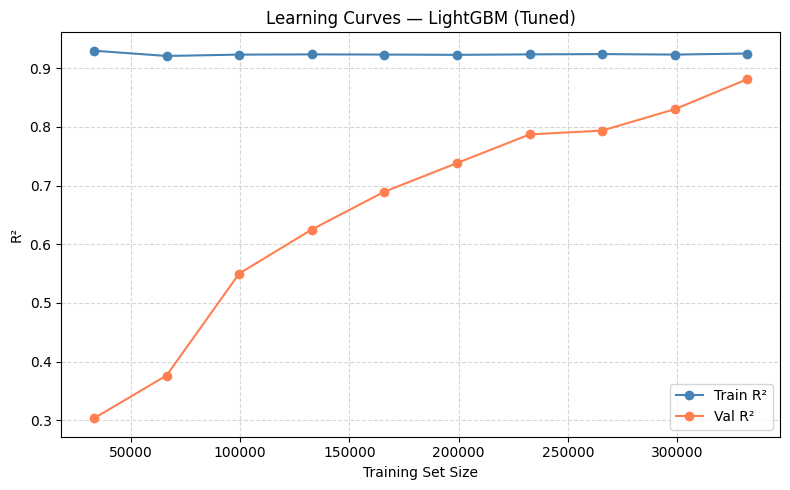

In [ ]:
train_sizes = np.linspace(0.1, 1.0, 10)
train_r2s_tuned, val_r2s_tuned = [], []

for frac in train_sizes:
    n_sub = int(len(X_train) * frac)
    X_sub, y_sub = X_train.iloc[:n_sub], y_train.iloc[:n_sub]

    m_tuned = lgb.LGBMRegressor(
        **study.best_params,
        n_estimators=lgb_tuned.best_iteration_,
        random_state=SEED,
        n_jobs=1,
        verbosity=-1,
    )
    m_tuned.fit(X_sub, y_sub)
    train_r2s_tuned.append(r2_score(y_sub, m_tuned.predict(X_sub)))
    val_r2s_tuned.append(r2_score(y_val,   m_tuned.predict(X_val)))

plt.figure(figsize=(8, 5))
plt.plot(train_sizes * len(X_train), train_r2s_tuned, 'o-', label='Train R²', color='steelblue')
plt.plot(train_sizes * len(X_train), val_r2s_tuned,   'o-', label='Val R²',   color='coral')
plt.xlabel('Training Set Size')
plt.ylabel('R²')
plt.title('Learning Curves — LightGBM (Tuned)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The learning curves reveal a notable pattern: train R² is consistently high
and nearly flat regardless of training set size, while val R² starts
low and rises steeply before plateauing at 0.88 with
the full training set. The persistent gap between train and val R² indicates
mild overfitting.

Importantly, val R² is still rising at full training size, suggesting the
model would benefit from more data if available. Therefore, the
current performance ceiling is partly a data volume constraint. The model is well-calibrated for the available
data but would likely improve further with additional transactions data
or richer property features.

### Ensemble Experiment: Linear Regression + LightGBM

As an additional experiment, a weighted ensemble of the Linear Regression
baseline and the tuned LightGBM was evaluated. The ensemble combined both
models' predictions as a weighted average:

    Ensemble prediction = w × LightGBM + (1 − w) × Linear Regression

The optimal weight `w` was selected by searching values from 0.0 to 1.0 in
steps of 0.05 and choosing the combination that maximised R² on the
validation set. The test set was not used during weight selection.

However,the Linear Regression contributed almost nothing to the final prediction. The ensemble R² matched the tuned LightGBM exactly on both validation and test
sets. This confirmed that the LR component adds no meaningful correction to an
already well-calibrated non-linear model.


### Saving the Tuned Model

The tuned LightGBM model and all encoding artefacts are saved together as a single `.joblib` file. This includes the model, the `area_name` target encoding map, the global median fallback, and the fitted label encoders — everything needed to make predictions without rerunning training.

**Set `SAVE_MODEL = True` the first time you run this notebook to save the file. On subsequent runs, set `SAVE_MODEL = False` to skip retraining and load directly from the saved file instead.**

In [ ]:
import joblib
import os

# Set to True during initial run, ONCE, to save the model after training
# Set to False on subsequent runs to skip retraining

SAVE_MODEL = True

MODEL_PATH = 'lgbm_tuned_artefacts.joblib'

if SAVE_MODEL:
    model_artefacts = {
        'model':           lgb_tuned,
        'area_target_map': area_target_map,
        'global_median':   global_median,
        'le_property':     le_property,
        'le_reg':          le_reg,
        'feature_cols':    feature_cols,
    }
    joblib.dump(model_artefacts, MODEL_PATH)
    print(f"Model saved to '{MODEL_PATH}'")
else:
    print("Model artefacts imported from file path.")

Model saved to 'lgbm_tuned_artefacts.joblib'


In [ ]:
# Load artefacts when skipping retraining
# This cell only executes when SAVE_MODEL = False
# On a fresh run without training, this restores everything needed for prediction

if not SAVE_MODEL:
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"No saved model found at '{MODEL_PATH}'. "
            "Run the notebook from the top with SAVE_MODEL = True first."
        )

    artefacts = joblib.load(MODEL_PATH)

    lgb_tuned      = artefacts['model']
    area_target_map = artefacts['area_target_map']
    global_median   = artefacts['global_median']
    le_property     = artefacts['le_property']
    le_reg          = artefacts['le_reg']
    feature_cols    = artefacts['feature_cols']

    print(f"Model loaded from '{MODEL_PATH}'")
    print(f"  Best iteration : {lgb_tuned.best_iteration_}")
    print(f"  Features       : {feature_cols}")

In [ ]:
def predict_property_price(
    area_name,
    procedure_area,
    rooms,
    year,
    month,
    has_parking,
    is_near_metro,
    property_type,
    reg_type,
    model=None,
):
    """
    Estimates Dubai residential property value in AED.

    Uses the tuned LightGBM model by default (whether trained in this session
    or loaded from a saved file). Pass a different model via the `model`
    parameter to override.

    Parameters
    ----------
    area_name       : str    e.g. 'Business Bay', 'Palm Jumeirah'
    procedure_area  : float  property area in sqft
    rooms           : float  0.5=Studio, 1=1 bed, 2=2 bed, 3=3 bed, 4=4 bed, 5=4+/Luxury
    year            : int    transaction year e.g. 2025
    month           : int    transaction month 1–12
    has_parking     : int    1 or 0
    is_near_metro   : int    1 or 0
    property_type   : str    'Unit' or 'Villa'
    reg_type        : str    'Off-Plan Properties' or 'Existing Properties'
    model           : fitted LGBMRegressor, optional
                      defaults to lgb_tuned (live or loaded)

    Returns
    -------
    Estimated property value in AED (float)
    """

    # To use passed model or fall back to lgb_tuned
    _model = model if model is not None else lgb_tuned

    # Area encoding
    area_enc = area_target_map.get(area_name, global_median)

    # Label encoding
    try:
        prop_type_enc = le_property.transform([property_type])[0]
    except ValueError:
        raise ValueError(
            f"Unknown property_type '{property_type}'. "
            f"Valid options: {list(le_property.classes_)}"
        )

    try:
        reg_type_enc = le_reg.transform([reg_type])[0]
    except ValueError:
        raise ValueError(
            f"Unknown reg_type '{reg_type}'. "
            f"Valid options: {list(le_reg.classes_)}"
        )

    input_data = pd.DataFrame([{
        'log_procedure_area': np.log(procedure_area),
        'rooms_numeric':      rooms,
        'year':               year,
        'month':              month,
        'has_parking':        has_parking,
        'is_near_metro':      is_near_metro,
        'area_encoded':       area_enc,
        'property_type_enc':  prop_type_enc,
        'reg_type_enc':       reg_type_enc,
    }])[feature_cols]

    return round(np.exp(_model.predict(input_data)[0]), 2)

### Example predictions

In [ ]:
examples = [
    ('Madinat Al Mataar',  500, 3, 2025, 1, 1, 0, 'Villa', 'Off-Plan Properties'),
    ('Wadi Al Safa 5',     145, 3, 2025, 2, 1, 0, 'Villa', 'Existing Properties'),
    ('Al Thanayah Fourth', 172, 2, 2025, 2, 1, 0, 'Villa', 'Existing Properties'),
    ('Wadi Al Safa 3',      96, 1, 2025, 2, 1, 0, 'Unit',  'Existing Properties'),
    ('Business Bay',      1200, 2, 2025, 6, 1, 1, 'Unit',  'Off-Plan Properties'),
    ('Palm Jumeirah',     3500, 4, 2025, 6, 1, 0, 'Villa', 'Existing Properties'),
]

print(f"{'Area':<25} {'Sqft':>6} {'Rooms':>5} {'Type':<6} {'Reg Type':<22} {'Estimated AED':>15}")
print("-" * 85)
for ex in examples:
    p = predict_property_price(*ex)
    print(f"{ex[0]:<25} {ex[1]:>6} {ex[2]:>5} {ex[7]:<6} {ex[8]:<22} {p:>15,.0f}")

Area                        Sqft Rooms Type   Reg Type                 Estimated AED
-------------------------------------------------------------------------------------
Madinat Al Mataar            500     3 Villa  Off-Plan Properties          4,588,074
Wadi Al Safa 5               145     3 Villa  Existing Properties          2,487,813
Al Thanayah Fourth           172     2 Villa  Existing Properties          3,376,860
Wadi Al Safa 3                96     1 Unit   Existing Properties          1,043,270
Business Bay                1200     2 Unit   Off-Plan Properties         11,406,618
Palm Jumeirah               3500     4 Villa  Existing Properties         13,648,501


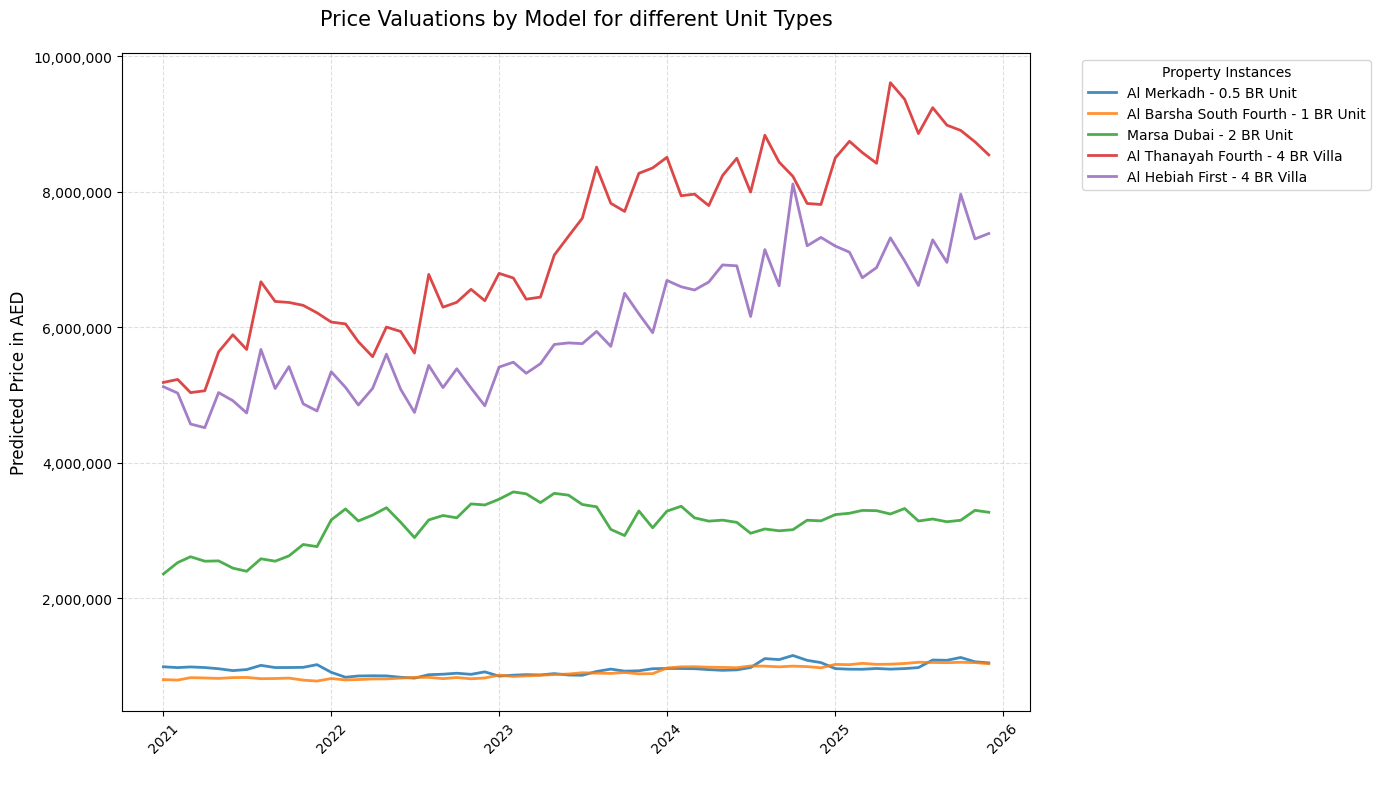

In [ ]:
instances = [
    ('Al Merkadh', 40, 0.5, 2026, 1, 1, 1, 'Unit', 'Off-Plan Properties'),
    ('Al Barsha South Fourth', 79, 1, 2026, 2, 1, 0, 'Unit', 'Existing Properties'),
    ('Marsa Dubai', 130, 2, 2026, 1, 1, 1, 'Unit', 'Off-Plan Properties'),
    ('Al Thanayah Fourth', 770, 4, 2026, 2, 1, 0, 'Villa', 'Off-Plan Properties'),
    ('Al Hebiah First', 798, 4, 2026, 1, 1, 1, 'Villa', 'Existing Properties'),
]

plt.figure(figsize=(14, 8))

for inst in instances:
    label = f"{inst[0]} - {inst[2]} BR {inst[7]}"
    dates = []
    prices = []

    for year in range(2021, 2026):
        for month in range(1, 13):
            params = list(inst)
            params[3] = year
            params[4] = month

            try:
                pred = predict_property_price(*params)
                dates.append(datetime(year, month, 1))
                prices.append(pred)
            except Exception as e:
                continue

    plt.plot(dates, prices, label=label, linewidth=2, alpha=0.85)

plt.title('Price Valuations by Model for different Unit Types', fontsize=15, pad=20)
plt.ylabel('Predicted Price in AED', fontsize=12)
plt.xlabel(' ', fontsize=12)

plt.grid(True, which="major", linestyle='--', alpha=0.4)

plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.xticks(rotation=45)
plt.legend(title="Property Instances", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

This chart shows how the model's valuations evolve across the 2021–2025
period for five representative property configurations held constant in all
characteristics except transaction date. It illustrates the temporal component
the model has learned from `year` and `month`.

All property types show a general upward trend consistent with observed Dubai
market appreciation. High-value villas (Al Thanayah Fourth 4BR, Al Hebiah
First 4BR) show the steepest absolute price growth, rising from ~AED 5–5.5M
in 2021 to ~AED 8.5–9.5M by late 2025.

Mid-range units (Marsa Dubai 2BR) show
moderate growth from ~AED 2.4M to ~AED 3.3M. Studio and 1-bedroom units
remain relatively flat.

This visualisation demonstrates the ability of the model to capture temporal
trends in the market.

## 9. Conclusion

This project is an end-to-end **residential property valuation model** for the Dubai market using 415,018 sales records from the Dubai Land Department (2021–2025).

The model answers the question: *"Given a property's characteristics, what is it worth at current market rates?"*.

Three models were built and evaluated on a time-based 80/10/10 train/validation/test split:

| Model | R² (Val) | R² (Test) | MAE % of Median (Test) |
|-------|----------|-----------|------------------------|
| Linear Regression | 0.675 | 0.697 | 33.7% |
| LightGBM (default) | 0.877 | 0.850 | 22.3% |
| LightGBM (tuned) | 0.881 | 0.850 | 22.1% |

The tuned LightGBM is the final model, explaining 85% of variance in unseen 2025 transaction prices with a typical valuation error of ~22% of median price.

Property size (`log_procedure_area`) and location (`area_encoded`) are the dominant valuation signals, consistent with how Dubai's market operates in practice.

Hyperparameter tuning via Optuna yielded marginal improvement over the default configuration, confirming the default LightGBM was already near-optimal for this feature set. Further gains would require richer property-level data.

The stable val/test gap (~0.03 R²) across both LightGBM models reflects genuine temporal distribution shift between the 2021–2024 training period and 2025 and not overfitting.

### Limitations

- **Model not for forecasting**: The model reflects market patterns from 2021–2025. The model should be used to value properties at current market rates, and retrained periodically as market conditions evolve.


- **No geospatial features**: `area_name` is encoded by median training price. Latitude/longitude or distance based features could be more informative.


- **Luxury segment excluded**: Transactions above the 98th price percentile were removed. The model is not suitable for ultra-luxury property valuations.


- **No property-level features**: The DLD dataset contains no information about floor level, view type, or developer, all of which significantly affect Dubai property prices. This represents the practical ceiling for this dataset.



### Possible Improvements

- Retrain periodically on a rolling window of the most recent transactions to keep valuations aligned with current market conditions.
- Add geospatial features like latitude/longitude, distance to airport. etc.
- Cluster rare areas (fewer than 100 training transactions) before target encoding to reduce noise from unstable area-level estimates.
- Incorporate macroeconomic context like oil price index, UAE GDP growth rate to help the model understand market cycles.
- Adding developer name as a target-encoded feature.

## 10. References

### Dataset

* Dubai Land Department. *Dubai Pulse Open Data Portal*.
  [https://data.dubai.gov.ae/en/l/470061](https://data.dubai.gov.ae/en/l/470061)

### Dataset (Hosted)

* *Dubai Real Estate Transactions*. Hugging Face.
  [https://huggingface.co/datasets/mohd3rfan/DLD_Transactions](https://huggingface.co/datasets/mohd3rfan/DLD_Transactions)

### Libraries

* Scikit-Learn. [https://scikit-learn.org/](https://scikit-learn.org/)
* Seaborn. [https://seaborn.pydata.org/](https://seaborn.pydata.org/)
* Matplotlib. [https://matplotlib.org/](https://matplotlib.org/)
* Optuna. [https://optuna.org/](https://optuna.org/)

### Technical Resources

* *What is Gradient Boosting?* IBM.
  [https://www.ibm.com/think/topics/gradient-boosting](https://www.ibm.com/think/topics/gradient-boosting)

* LightGBM Python API Documentation.
  [https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMModel.html](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMModel.html)

* *LightGBM (Light Gradient Boosting Machine)*. GeeksforGeeks.
  [https://www.geeksforgeeks.org/machine-learning/lightgbm-light-gradient-boosting-machine/](https://www.geeksforgeeks.org/machine-learning/lightgbm-light-gradient-boosting-machine/)

### Book

* Géron, Aurélien. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems*. 2nd ed., O’Reilly, 2019.
